# Case Study 2 — market comparison with retrieval-augmented generation

This notebook builds a small retrieval-augmented generation (RAG) system end to end and uses it to pull three figures out of the 2025 annual reports of AXA, Generali and Zurich — solvency ratios, EUR discount curves and insurer financial strength ratings — as clean, comparable data.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/advanced-genai-actuarial/blob/main/notebooks/04_cs2_rag_market_comparison/04_cs2_rag_market_comparison.ipynb)

EAA seminar **E0572 — Advanced Applications of Generative AI in Actuarial Science**, Vilnius, 1–2 October 2026. Lecturer: Dr Simon Hatzesberger.

Repository: [simonhatzesberger/advanced-genai-actuarial](https://github.com/simonhatzesberger/advanced-genai-actuarial)

The case study, its prompts, its output schemas, its ground truth and its scoring rules come from the published article, whose research notebook this one re-implements in the seminar's own style:

> Hatzesberger S, Nonneman I (2026) Advanced applications of generative AI in actuarial science: case studies beyond ChatGPT. *European Actuarial Journal* 16(2):481–523. https://doi.org/10.1007/s13385-026-00464-9

Section 5 of `02_llm_techniques` was a signpost with no code, promising a notebook that builds a small RAG system end to end. This is that notebook. Where the research notebook used LangChain, this one uses nothing but the plain `openai` package, so that every step is a few lines you can read.

**Reading it and running it.** Like the other notebooks, this one **ships with its outputs**: every number and every answer below was produced by actually running it, and you can read all of them without a key. Unlike the other case studies, though, it has **no recorded answers to fall back on**: running it needs a key (notebook 00, section 6) and costs about USD 0.65 on a first run — the cold-run estimate in the ledger at the end of the notebook. If you run it yourself, the model answers, pass counts, token counts and costs will differ from the saved ones — GPT-6 Luna's in particular — and the commentary describes the saved run, not yours.

The saved run cost USD 0.54 at list prices on 22 September 2026, a little less than a first run, because OpenAI's prompt cache still held some prompts from an earlier run; with no caching at all it would have cost USD 1.03. About USD 0.28 of it is one-off: embedding the three reports (USD 0.17) and, in the extra exercise, 30,000 policy descriptions (USD 0.11). Both are kept in `_local/` together with the downloads, so a second run in the same session, or on your own machine, reads them from there and pays only for the model calls. In Colab, `_local/` lives on the temporary machine and is lost when the session ends.

## Learning objectives

After working through this notebook you will be able to:

- **explain** the three stages of a RAG pipeline — preprocessing, prompt augmenting and response generation — and point to the line of code that does each;
- **inspect** every interim result: the extracted text, the chunks, the embedding vectors, the similarity scores and the exact prompt the model receives;
- **force** the answers into Pydantic schemas, so that three reports become one comparison table;
- **score** the answers against a ground truth with deterministic rules, and tell a retrieval failure from a generation failure;
- **benchmark** three models on the same retrieved evidence and read the result with appropriate caution;
- **try** the same embedding idea on a pricing problem, in the extra exercise at the end.

## Contents

1. [Setup](#1-setup)
2. [The business problem and the three reports](#2-the-business-problem-and-the-three-reports)
3. [Stage 1: preprocessing](#3-stage-1-preprocessing)
4. [Stage 2: prompt augmenting (retrieval)](#4-stage-2-prompt-augmenting-retrieval)
5. [Stage 3: response generation](#5-stage-3-response-generation)
6. [Checking the answers](#6-checking-the-answers)
7. [A small benchmark](#7-a-small-benchmark)
8. [What to take away](#8-what-to-take-away)
9. [Extra exercise: embeddings for insurance pricing](#9-extra-exercise-embeddings-for-insurance-pricing)

---

## 1 Setup

Two cells, run once. The first makes sure the PDF reader is installed; the second fixes the models and the retrieval parameters, finds your key without ever printing it, and sets up a small ledger that records the tokens and the cost of every paid call the notebook makes.

The ledger needs one explanation. OpenAI caches prompts automatically: input tokens it has seen recently from the same organisation — typically within the last few minutes, sometimes longer — are billed at a tenth of the price. So what a call costs depends on what was sent shortly before — by you, or by anyone else using the same key. The ledger therefore shows three figures: what this run actually cost, a **cold-run estimate** (every prompt billed at full price the first time this run sends it, repeats at what they actually cost), and the price with no caching at all.

Colab already provides everything this notebook needs except **PyMuPDF**, the library that reads PDF files. The cell below installs it only if the import fails, at the version pinned in the repository's `requirements.txt`, and installs nothing else.

In [1]:
# Colab ships everything this notebook needs except PyMuPDF, the PDF reader.
# It is installed only if the import fails, at the version the repository pins.
try:
    import pymupdf
except ImportError:
    %pip install -q pymupdf==1.28.2
    import pymupdf

print(f"[PASS] PyMuPDF {pymupdf.__version__} is available for reading the PDF reports.")

[PASS] PyMuPDF 1.28.2 is available for reading the PDF reports.


A few words on the two models before the cell that fixes them.

- **`gpt-6-luna`** writes the answers. It was released on 22 September 2026 and is the cheapest model of the GPT-6 family. At the time of writing it exists only under this alias, not as a dated snapshot, so — unlike the dated GPT-5.4 models in section 7 — its behaviour may change without the name changing.
- **`text-embedding-3-large`** turns text into vectors for retrieval. It is the embedding model of the article, with 3,072 dimensions, so the article's retrieval parameters (the top 10 chunks, a similarity threshold of 0.30) keep their meaning.

The prices are OpenAI's list prices, retrieved from its pricing page on 22 September 2026. GPT-6 Luna costs USD 0.10 per million input tokens, against USD 2.50 for GPT-5.4, and USD 0.125 per million input tokens it writes to the prompt cache. The saved run's costs were computed before cache writes were counted: at USD 0.025 per million more for a write, the 46,183 uncached input tokens of its GPT-6 Luna calls add at most USD 0.0012 to its USD 0.54, and the cold-run estimate of USD 0.65, in which a first send also writes its prompt to the cache, rises by at most USD 0.0025.

In [2]:
import hashlib
import json
import os
import re
import shutil
import textwrap
import threading
import time
import warnings
from bisect import bisect_right
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from typing import List, Literal, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import tiktoken
from openai import APIError, OpenAI, RateLimitError
from pydantic import BaseModel

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 200)

# The generation model for the walkthrough, and the embedding model for retrieval.
MODEL = "gpt-6-luna"
EMBED_MODEL = "text-embedding-3-large"  # 3,072 dimensions, as in the article

# The article's retrieval parameters, kept global so that every step below uses the same ones.
CHUNK_SIZE = 2_000  # maximum characters per chunk
OVERLAP = 300       # characters shared by two consecutive chunks
TOP_N = 10          # chunks handed to the model per question
THRESHOLD = 0.30    # minimum cosine similarity a chunk needs to qualify
SEED = 42

# Downloads and caches live here, relative to where the notebook runs. A second run in the same
# session (or on your own machine) reads them instead of downloading and embedding again.
LOCAL_DIR = Path("_local")
PDF_DIR = LOCAL_DIR / "pdfs"
EMB_DIR = LOCAL_DIR / "embeddings"
DATA_DIR = LOCAL_DIR / "data"
for directory in (PDF_DIR, EMB_DIR, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# List prices in USD per million tokens: (input, cached input, cache write, output).
# OpenAI pricing page, standard processing, as retrieved on 22 September 2026. Only GPT-6 Luna has a
# cache-write price: for the other models a write costs the input price.
PRICES_USD_PER_MTOK = {
    "gpt-6-luna": (0.10, 0.01, 0.125, 0.50),
    "gpt-5.4-mini-2026-03-17": (0.75, 0.075, None, 4.50),
    "gpt-5.4-2026-03-05": (2.50, 0.25, None, 15.00),
    "text-embedding-3-large": (0.13, None, None, None),
    "text-embedding-3-small": (0.02, None, None, None),
}

# The article ran every model at temperature 0. The GPT-5.4 models accept temperature only at
# reasoning effort "none", their default; at "low" or higher they reject it with an error.
# GPT-6 Luna accepts it only at effort "none" too, but runs here at its default effort, "medium",
# at which it rejects temperature. So temperature=0 goes only to the two GPT-5.4 models, together
# with an explicit reasoning effort of "none".
SAMPLING_OPTIONS = {
    "gpt-5.4-mini-2026-03-17": {"temperature": 0, "reasoning": {"effort": "none"}},
    "gpt-5.4-2026-03-05": {"temperature": 0, "reasoning": {"effort": "none"}},
}


def find_api_key(name: str = "OPENAI_API_KEY") -> str | None:
    """Return the key if this environment can see one, otherwise None. Never raises."""
    try:
        from google.colab import userdata  # available on Colab only

        value = userdata.get(name)
        if value:
            return value
    except Exception:
        # Not on Colab, or the secret does not exist, or notebook access is off.
        pass
    return os.environ.get(name) or None


key = find_api_key()
client = OpenAI(api_key=key, max_retries=5) if key else None


def require_client() -> None:
    # Stop with a clear message, rather than a traceback, when a cell needs the API and no key is visible.
    if client is None:
        raise RuntimeError("No OPENAI_API_KEY is visible - see notebook 00, section 6.")


LEDGER: list[dict] = []   # one row per paid API call made in this session
_SEEN_PROMPTS: set = set()  # prompts this session has already sent, for the cold-run estimate
_LEDGER_LOCK = threading.Lock()


def log_usage(model: str, purpose: str, input_tokens: int, cached_tokens: int = 0, output_tokens: int = 0,
              prompt_key: str | None = None, cache_write_tokens: int = 0) -> dict:
    """Record one paid call in the ledger and return its row, with the cost in USD at the list prices above."""
    price_in, price_cached, price_write, price_out = PRICES_USD_PER_MTOK[model]
    if price_write is None:  # no cache-write price: a write costs the input price
        price_write = price_in
    cost = (
        (input_tokens - cached_tokens - cache_write_tokens) * price_in
        + cached_tokens * (price_cached if price_cached is not None else price_in)
        + cache_write_tokens * price_write
        + output_tokens * (price_out or 0.0)
    ) / 1_000_000
    # With no caching at all, every input token pays the input price: nothing is read from or written to the cache.
    uncached = (input_tokens * price_in + output_tokens * (price_out or 0.0)) / 1_000_000
    # A cold run finds nothing in the cache, so it writes what this run read from the cache as well as what it wrote.
    cold = uncached + (cached_tokens + cache_write_tokens) * (price_write - price_in) / 1_000_000
    with _LEDGER_LOCK:
        # Cold-run estimate: the first time this run sends a prompt it pays full price; a repeat
        # costs what it actually cost, because it would be cached in a cold run as well.
        first_time = prompt_key is not None and prompt_key not in _SEEN_PROMPTS
        if prompt_key is not None:
            _SEEN_PROMPTS.add(prompt_key)
        row = {
            "purpose": purpose,
            "model": model,
            "input_tokens": input_tokens,
            "cached_tokens": cached_tokens,
            "cache_write_tokens": cache_write_tokens,
            "output_tokens": output_tokens,
            "cost_usd": cost,
            "cost_usd_cold_run": cold if first_time else cost,
            "cost_usd_no_cache": uncached,
        }
        LEDGER.append(row)
    return row


COST_COLUMNS = ["cost_usd", "cost_usd_cold_run", "cost_usd_no_cache"]


def spend_report() -> pd.DataFrame:
    """Calls, tokens and cost of everything this session has paid for, by purpose and model."""
    counts = ["calls", "input_tokens", "cached_tokens", "cache_write_tokens", "output_tokens"]
    if not LEDGER:
        return pd.DataFrame(columns=counts + COST_COLUMNS)
    table = (
        pd.DataFrame(LEDGER)
        .groupby(["purpose", "model"], sort=False)
        .agg(
            calls=("cost_usd", "size"),
            input_tokens=("input_tokens", "sum"),
            cached_tokens=("cached_tokens", "sum"),
            cache_write_tokens=("cache_write_tokens", "sum"),
            output_tokens=("output_tokens", "sum"),
            **{column: (column, "sum") for column in COST_COLUMNS},
        )
    )
    table.loc[("total", ""), :] = table.sum()
    table[counts] = table[counts].astype(int)
    return table.round({column: 4 for column in COST_COLUMNS})


if key:
    print(f"[PASS] A key named OPENAI_API_KEY is visible ({len(key)} characters long).")
    print("       Its value is never printed - not here, not anywhere.")
else:
    print("[ATTENTION] No key named OPENAI_API_KEY is visible to this notebook.")
    print("            Every model call below needs one; notebook 00, section 6 explains how.")

print(f"Generation model : {MODEL}")
print(f"Embedding model  : {EMBED_MODEL}")
print(f"Retrieval        : chunks of {CHUNK_SIZE:,} characters, {OVERLAP} overlap, "
      f"top {TOP_N} at or above a cosine similarity of {THRESHOLD:.2f}")
print(f"Local cache      : {LOCAL_DIR}/ (next to where the notebook runs)")

[PASS] A key named OPENAI_API_KEY is visible (164 characters long).
       Its value is never printed - not here, not anywhere.
Generation model : gpt-6-luna
Embedding model  : text-embedding-3-large
Retrieval        : chunks of 2,000 characters, 300 overlap, top 10 at or above a cosine similarity of 0.30
Local cache      : _local/ (next to where the notebook runs)


---

## 2 The business problem and the three reports

### Why it matters for actuaries

Comparing yourself with the market is routine work: where does our solvency ratio sit against the large groups, how do our IFRS 17 discount rates compare with theirs, which agencies rate them and how? The figures are all public. They are also buried in reports of several hundred pages each, and every group lays its report out differently:

- the **solvency ratio** is a single number with a label, but the label differs — Solvency II for AXA and Generali, the Swiss Solvency Test (SST) for Zurich;
- the **discount curve** is a table of varying length, somewhere in the notes to the IFRS 17 accounts, next to curves for other currencies and for the previous year;
- the **financial strength ratings** are a short list of records, printed next to issuer credit and debt ratings that look almost the same.

A single number, a table and a list of records: three different kinds of answer, which is exactly why the article chose them. Doing this by hand for three groups is an afternoon; for twenty groups every year it is a process. RAG turns it into a pipeline you can inspect at every step.

### The three reports

The cell below downloads the three 2025 annual reports from the groups' own websites — the same URLs the article used — and keeps them in `_local/pdfs/`, together with a note of the URL and a checksum. On a second run in the same session it reads them from there instead, unless a file is incomplete or its URL has changed. In Colab, `_local/` lives on the temporary machine and is lost when the session ends. Some report servers refuse Python's default identification, so the request identifies itself as an ordinary browser.

In [3]:
ANNUAL_REPORT_URLS = {
    "AXA": "https://www-axa-com.cdn.prismic.io/www-axa-com/ab1gEB5fn6DF3CqE_axa_urd2025_accessible_va.pdf",
    "Generali": "https://www.generali.com/doc/jcr:b569c750-290c-4868-9b6f-655e0349451c/Annual%20Integrated%20Report%20and%20Consolidated%20Financial%20Statements%202025_Generali%20Group_final.pdf/lang:en/Annual_Integrated_Report_and_Consolidated_Financial_Statements_2025_Generali_Group_final.pdf",
    "Zurich": "https://edge.sitecorecloud.io/zurichinsur6934-zwpcorp-prod-ae5e/media/project/zurich/dotcom/investor-relations/docs/financial-reports/2025/annual-report-2025-en.pdf",
}
COMPANIES = list(ANNUAL_REPORT_URLS)

# Some report servers refuse Python's default user agent, so we identify as an ordinary browser.
BROWSER_HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/140.0 Safari/537.36"
}


def ends_look_right(path: Path, head: bytes, tail: bytes) -> bool:
    # A complete PDF starts with %PDF- and ends with %%EOF; a parquet file starts and ends with PAR1.
    if not path.exists() or path.stat().st_size < 1024:
        return False
    with path.open("rb") as handle:
        start = handle.read(len(head))
        handle.seek(-1024, os.SEEK_END)
        end = handle.read()
    return start == head and tail in end


def download(url: str, path: Path, head: bytes, tail: bytes) -> str:
    # Download once and keep the file with a note of its URL and checksum. A cached file is reused
    # only if it is complete and came from the same URL; the download goes to a temporary file first.
    note = path.with_name(path.name + ".json")
    if note.exists() and ends_look_right(path, head, tail):
        if json.loads(note.read_text(encoding="utf-8")).get("url") == url:
            return "read from _local/"
    response = requests.get(url, headers=BROWSER_HEADERS, timeout=300)
    response.raise_for_status()
    partial = path.with_name(path.name + ".part")
    partial.write_bytes(response.content)
    if not ends_look_right(partial, head, tail):
        partial.unlink()
        raise ValueError(f"{url} did not return a complete {path.suffix} file")
    partial.replace(path)
    digest = hashlib.sha256(response.content).hexdigest()
    note.write_text(json.dumps({"url": url, "sha256": digest, "bytes": len(response.content)}, indent=2), encoding="utf-8")
    return "downloaded now"


REPORT_PATHS = {}
rows = []
for company, url in ANNUAL_REPORT_URLS.items():
    path = PDF_DIR / f"{company}_2025_annual_report.pdf"
    source = download(url, path, head=b"%PDF-", tail=b"%%EOF")
    REPORT_PATHS[company] = path
    with pymupdf.open(path) as doc:
        page_count = doc.page_count
    rows.append(
        {"company": company, "pages": page_count, "size (MB)": round(path.stat().st_size / 1e6, 1), "source": source}
    )

reports = pd.DataFrame(rows).set_index("company")
display(reports)
print(f"[PASS] {len(REPORT_PATHS)} annual reports, {reports['pages'].sum():,} pages in total.")

,pages,size (MB),source
company,,,
AXA,588,16.0,downloaded now
Generali,458,4.6,downloaded now
Zurich,430,22.0,downloaded now


[PASS] 3 annual reports, 1,476 pages in total.


Close to 1,500 pages between three groups. Nobody reads that for three figures each — and a language model cannot read it either: at roughly a quarter of a token per character, each report is several hundred thousand tokens, and the three together are over a million. That is the gap RAG fills. We never show the model a whole report; we show it the ten passages most likely to contain the answer.

The rest of the notebook follows the article's three stages, shown in its figure of the 3-stage approach:

| Stage | What happens | Done |
| --- | --- | --- |
| **1 Preprocessing** | PDF → text → clean text → chunks → one embedding vector per chunk | once per report |
| **2 Prompt augmenting** | embed the question, rank all chunks by cosine similarity, paste the best ten into the prompt | once per question |
| **3 Response generation** | send the augmented prompt, receive an answer that must fit a Pydantic schema | once per question and model |

---

## 3 Stage 1: preprocessing

### Why it matters for actuaries

Stage 1 decides what the model can ever see. A figure that is lost here — on a page that is only a picture, or cut in half at a chunk boundary — cannot be retrieved later, however good the question or the model. Preprocessing is unglamorous, and it is where most RAG systems quietly fail.

### 3.1 From PDF to text

PyMuPDF reads the text layer of every page. It is one of several good choices (`pdfplumber`, `pypdf`, `markitdown` and others would do too). Note what it cannot do: a page that is only a picture has no text layer, and PyMuPDF does not read pixels — that would need OCR.

In [4]:
def extract_pages(pdf_path: Path) -> list[str]:
    # Plain text of every page of one PDF, in page order.
    with pymupdf.open(pdf_path) as doc:
        return [page.get_text() for page in doc]


started = time.time()
RAW_PAGES = {company: extract_pages(path) for company, path in REPORT_PATHS.items()}
print(f"Text extracted from {sum(len(p) for p in RAW_PAGES.values()):,} pages in {time.time() - started:.1f} seconds.")

pd.DataFrame(
    [
        {
            "company": company,
            "pages": len(pages),
            "characters": sum(len(page) for page in pages),
            "pages without any text": sum(1 for page in pages if not page.strip()),
        }
        for company, pages in RAW_PAGES.items()
    ]
).set_index("company")

Text extracted from 1,476 pages in 4.5 seconds.


,pages,characters,pages without any text
company,,,
AXA,588,1969238,3
Generali,458,1515508,18
Zurich,430,1377261,0


### 3.2 Cleaning

The raw text is full of invisible debris: trailing spaces, runs of blank lines, non-breaking spaces. The research notebook's cleaning step (the article's "text cleansing") normalises whitespace and nothing else — every word and every number survives. Here is page 21 of the AXA report, the start of its ratings section, before and after. We print it with `repr()` so that the invisible characters become visible: `\n` is a line break, `\xa0` a non-breaking space.

In [5]:
def clean_text(text: str) -> str:
    # Normalise whitespace while keeping every word and number - the research notebook's cleaning step.
    cleaned = re.sub(r"[ \t]+", " ", text)                               # runs of spaces or tabs -> one space
    cleaned = "\n".join(line.strip() for line in cleaned.splitlines())  # trim both ends of every line
    cleaned = re.sub(r"\n\s*\n+", "\n\n", cleaned)                      # at most one blank line in a row
    return cleaned.strip()


page = RAW_PAGES["AXA"][20]  # page 21 of the PDF: the start of AXA's ratings section
print("RAW     - the first 420 characters:")
print(textwrap.fill(repr(page[:420]), width=110))
print()
print("CLEANED - the first 420 characters:")
print(textwrap.fill(repr(clean_text(page)[:420]), width=110))

RAW     - the first 420 characters:
'The AXA Group\n1.5\xa0Ratings\n1.5\nRatings\nThe Group is rated by recognized rating agencies which assess
\nthe financial strength and the creditworthiness of the Company \nand certain of its insurance subsidiaries.
The ratings set forth \nbelow are subject to revision or withdrawal at any time by the \nassigning rating
agency in its sole discretion. Credit ratings are \nintended to reflect the ability of AXA to meet its paymen'

CLEANED - the first 420 characters:
'The AXA Group\n1.5\xa0Ratings\n1.5\nRatings\nThe Group is rated by recognized rating agencies which
assess\nthe financial strength and the creditworthiness of the Company\nand certain of its insurance
subsidiaries. The ratings set forth\nbelow are subject to revision or withdrawal at any time by the\nassigning
rating agency in its sole discretion. Credit ratings are\nintended to reflect the ability of AXA to meet its
payment\nobl'


Compare `assess \nthe` in the raw text with `assess\nthe` in the cleaned one: the trailing space before each line break has gone. The non-breaking space in `1.5\xa0Ratings` stays, because it sits inside a line; lines holding nothing but a non-breaking space, of which there are several further down this page, disappear altogether. Not a word or a digit has changed.

Now the whole reports. We clean page by page and join the pages with a blank line, remembering where each page starts in the joined text — that is what lets us say later which **page** a retrieved passage came from.

In [6]:
def build_document(pages: list[str]) -> tuple[str, list[int], list[int]]:
    # Clean every page and join them with a blank line. Also return where each page starts
    # in the joined text, and its page number, so that any position can be traced to its page.
    parts, starts, page_numbers = [], [], []
    offset = 0
    for number, raw in enumerate(pages, start=1):
        cleaned = clean_text(raw)
        if not cleaned:
            continue  # a page without text contributes nothing
        if parts:
            offset += 2  # the blank line that joins this page to the previous one
        starts.append(offset)
        page_numbers.append(number)
        parts.append(cleaned)
        offset += len(cleaned)
    return "\n\n".join(parts), starts, page_numbers


DOCUMENTS = {company: build_document(pages) for company, pages in RAW_PAGES.items()}

pd.DataFrame(
    [
        {
            "company": company,
            "raw characters": sum(len(page) for page in RAW_PAGES[company]),
            "clean characters": len(text),
            "removed": f"{1 - len(text) / sum(len(page) for page in RAW_PAGES[company]):.1%}",
        }
        for company, (text, _, _) in DOCUMENTS.items()
    ]
).set_index("company")

,raw characters,clean characters,removed
company,,,
AXA,1969238,1935175,1.7%
Generali,1515508,1503795,0.8%
Zurich,1377261,1355728,1.6%


### 3.3 Chunking

Even cleaned, a report is far too long for one prompt, so we cut it into **chunks** with the article's simple sliding window: at most 2,000 characters each, and every chunk starts 1,700 characters after the previous one. Consecutive chunks therefore share 300 characters, so that a sentence cut by one boundary still appears whole in the neighbouring chunk.

It is deliberately naive — it cuts through sentences, tables and headings alike. Smarter chunkers that respect paragraphs or table boundaries exist, and they help; the point here is that even the naive one works surprisingly well.

Page numbers below are positions in the PDF file. They can differ from the numbers printed on the pages.

In [7]:
def create_chunks(text: str, chunk_size: int = CHUNK_SIZE, overlap: int = OVERLAP) -> list[tuple[int, str]]:
    # Split text into overlapping character windows; return (start position, chunk text) pairs.
    step = chunk_size - overlap
    return [(start, text[start : start + chunk_size]) for start in range(0, len(text), step)]


CHUNKS: list[dict] = []
for company, (text, starts, page_numbers) in DOCUMENTS.items():
    for position, (start, chunk) in enumerate(create_chunks(text), start=1):
        first = page_numbers[bisect_right(starts, start) - 1]
        last = page_numbers[bisect_right(starts, start + len(chunk) - 1) - 1]
        CHUNKS.append(
            {
                "company": company,
                "chunk_id": f"{company}-{position:04d}",
                "pages": str(first) if first == last else f"{first}-{last}",
                "text": chunk,
            }
        )

chunk_table = pd.DataFrame(CHUNKS)
chunk_table["characters"] = chunk_table["text"].str.len()
summary = chunk_table.groupby("company", sort=False).agg(
    chunks=("chunk_id", "size"), mean_characters=("characters", "mean"), shortest=("characters", "min")
)
summary["mean_characters"] = summary["mean_characters"].round(0).astype(int)
display(summary)
print(f"[PASS] {len(CHUNKS):,} chunks in total.")

,chunks,mean_characters,shortest
company,,,
AXA,1139,1999,575
Generali,885,1999,995
Zurich,798,1999,828


[PASS] 2,822 chunks in total.


Every chunk but the last in each report is exactly 2,000 characters long; the last one is simply whatever is left over. Here is one complete chunk — the one holding the values of AXA's ratings table, which will matter later. Notice that it starts and ends wherever the window happened to fall, in mid-sentence if need be, and that the table has been flattened into one cell per line: the PDF's rows and columns are gone, and only their reading order survives.

In [8]:
def find_chunk(company: str, *phrases: str) -> int:
    # Position in CHUNKS of the first chunk of this company containing every phrase (line breaks ignored).
    for position, chunk in enumerate(CHUNKS):
        flat = " ".join(chunk["text"].split())
        if chunk["company"] == company and all(phrase in flat for phrase in phrases):
            return position
    raise LookupError(f"No {company} chunk contains {phrases}")


example = find_chunk("AXA", "A+ Superior")
chunk = CHUNKS[example]
print(f"{chunk['chunk_id']}  |  PDF page {chunk['pages']}  |  {len(chunk['text']):,} characters")
print("-" * 100)
print(chunk["text"])

AXA-0024  |  PDF page 21  |  2,000 characters
----------------------------------------------------------------------------------------------------
he relevant ratings for the Company and its principal insurance subsidiaries were as follows:

Agency
Date of last review
AXA SA
Insurer financial strength ratings
AXA's credit ratings
AXA’s principal
insurance subsidiaries
Outlook
Senior
debt of the
Company
Short‑term
debt of the
Company
S&P Global Ratings
October 3, 2025
A+
AA-
Positive
A+
A‑1+
Moody’s Investors Service
October 8, 2025
Aa2
Aa2
Stable
Aa3
P‑1
A.M. Best Rating Services
October 9, 2025
A+ Superior
-
Stable
aa Superior
-

1.5.2 Extra‑financial ratings
AXA Group’s extra‑financial performance is rated by a number of
specialists on Environmental, Social and Governance (ESG) topics,
including investors, brokers and rating agencies as well as specialist
organizations focused on single sustainability themes.
AXA Group’s main extra‑financial ratings as of the date of this
Document ar

And here is the overlap at work. The window boundary fell right inside that table: the previous chunk ends with the table's column headings, and this one starts with them. The last 300 characters of the previous chunk are, character for character, the first 300 characters of this one — which is what keeps the headings attached to the ratings they describe.

In [9]:
previous_chunk, this_chunk = CHUNKS[example - 1], CHUNKS[example]
tail, head = previous_chunk["text"][-OVERLAP:], this_chunk["text"][:OVERLAP]

print(f"Last {OVERLAP} characters of {previous_chunk['chunk_id']}:")
print(textwrap.indent(tail, "    "))
print()
print(f"First {OVERLAP} characters of {this_chunk['chunk_id']}:")
print(textwrap.indent(head, "    "))
print()
print("[PASS] identical" if tail == head else "[ATTENTION] the two pieces differ")

Last 300 characters of AXA-0023:
    he relevant ratings for the Company and its principal insurance subsidiaries were as follows:

    Agency
    Date of last review
    AXA SA
    Insurer financial strength ratings
    AXA's credit ratings
    AXA’s principal
    insurance subsidiaries
    Outlook
    Senior
    debt of the
    Company
    Short‑term
    debt of the
    Company
    S&P Global

First 300 characters of AXA-0024:
    he relevant ratings for the Company and its principal insurance subsidiaries were as follows:

    Agency
    Date of last review
    AXA SA
    Insurer financial strength ratings
    AXA's credit ratings
    AXA’s principal
    insurance subsidiaries
    Outlook
    Senior
    debt of the
    Company
    Short‑term
    debt of the
    Company
    S&P Global

[PASS] identical


### 3.4 Embeddings

An **embedding** turns a piece of text into a long list of numbers — a vector — placed so that texts with similar meaning land close together. `text-embedding-3-large` returns 3,072 numbers per chunk. Nobody reads these numbers individually; what matters is the angle between two vectors, which section 3.5 makes concrete.

We embed all chunks in batches of 128 (the API accepts a list of texts per call), two batches at a time, and keep the result in `_local/embeddings/` under a name that includes the model and a fingerprint of the chunk texts. On a second run in the same session the vectors are read from there — unless the chunks have changed, in which case the fingerprint no longer matches and the texts are embedded afresh. Every batch is saved the moment it arrives, so a run that is interrupted or hits the rate limit — likely enough when a whole room shares one key — resumes where it stopped instead of paying again from the start.

In [10]:
def embed_texts(texts: list[str], model: str, batch_size: int, purpose: str, batch_dir: Path,
                workers: int = 2) -> tuple[np.ndarray, int]:
    # Embed a list of texts in batches, two at a time. Every finished batch is saved in batch_dir at once,
    # so a run that is interrupted or rate-limited resumes where it stopped without paying again.
    require_client()
    batch_dir.mkdir(parents=True, exist_ok=True)
    batches = [texts[i : i + batch_size] for i in range(0, len(texts), batch_size)]

    def embed_batch(index: int) -> tuple[np.ndarray, int]:
        done = batch_dir / f"batch_{index:04d}.npz"
        if done.exists():  # kept from an earlier, interrupted run
            saved = np.load(done)
            return saved["vectors"], int(saved["tokens"])
        for attempt in range(1, 5):
            try:
                response = client.embeddings.create(model=model, input=batches[index])
                break
            except RateLimitError:
                if attempt == 4:
                    raise RuntimeError("The embedding API is still rate-limited. Wait a minute and run this cell "
                                       "again: the batches already embedded are kept and will not be paid for twice.")
                time.sleep(30 * attempt)  # a longer pause than the client's own retries
        log_usage(model, purpose, response.usage.total_tokens)  # one ledger row per API call
        vectors = np.array([item.embedding for item in response.data], dtype=np.float32)
        partial = batch_dir / f"batch_{index:04d}.part.npz"
        np.savez(partial, vectors=vectors, tokens=np.array(response.usage.total_tokens))
        partial.replace(done)
        return vectors, response.usage.total_tokens

    with ThreadPoolExecutor(max_workers=workers) as pool:
        results = list(pool.map(embed_batch, range(len(batches))))
    return np.concatenate([vectors for vectors, _ in results]), sum(tokens for _, tokens in results)


def cached_embeddings(name: str, texts: list[str], model: str, batch_size: int, purpose: str) -> tuple[np.ndarray, dict]:
    # The cache file is named after what it holds - its name, the model and a fingerprint of the texts -
    # so that variants live side by side and a changed prompt or model never overwrites the old vectors.
    fingerprint = hashlib.sha256(chr(30).join(texts).encode("utf-8")).hexdigest()
    stem = f"{name}_{model}_{fingerprint[:12]}"
    vector_file, info_file = EMB_DIR / f"{stem}.npy", EMB_DIR / f"{stem}.json"
    if vector_file.exists() and info_file.exists():
        vectors = np.load(vector_file)
        info = json.loads(info_file.read_text(encoding="utf-8"))
        if vectors.shape[0] == len(texts) and info.get("fingerprint") == fingerprint:
            return vectors, {**info, "source": "read from _local/ - no API call this time"}
    started = time.time()
    batch_dir = EMB_DIR / f"{stem}_batches"
    vectors, tokens = embed_texts(texts, model, batch_size, purpose, batch_dir)
    info = {
        "model": model,
        "texts": len(texts),
        "tokens": tokens,
        "cost_usd": tokens * PRICES_USD_PER_MTOK[model][0] / 1_000_000,
        "seconds": round(time.time() - started, 1),
        "fingerprint": fingerprint,
    }
    partial = EMB_DIR / f"{stem}.part.npy"
    np.save(partial, vectors)
    partial.replace(vector_file)
    info_file.write_text(json.dumps(info, indent=2), encoding="utf-8")  # written last: marks the cache complete
    shutil.rmtree(batch_dir, ignore_errors=True)
    return vectors, {**info, "source": "embedded now"}


CHUNK_VECTORS, embedding_info = cached_embeddings(
    "rag_chunks", [c["text"] for c in CHUNKS], EMBED_MODEL, batch_size=128, purpose="embed chunks"
)

print(f"Source          : {embedding_info['source']}")
print(f"Vectors         : {CHUNK_VECTORS.shape[0]:,} chunks x {CHUNK_VECTORS.shape[1]:,} dimensions")
print(f"Tokens embedded : {embedding_info['tokens']:,}  (about {embedding_info['tokens'] / len(CHUNKS):.0f} per chunk)")
print(f"Cost            : USD {embedding_info['cost_usd']:.4f} at USD {PRICES_USD_PER_MTOK[EMBED_MODEL][0]} per million tokens")
print(f"Time            : {embedding_info['seconds']} seconds when the vectors were computed")

Source          : embedded now
Vectors         : 2,822 chunks x 3,072 dimensions
Tokens embedded : 1,339,697  (about 475 per chunk)
Cost            : USD 0.1742 at USD 0.13 per million tokens
Time            : 14.9 seconds when the vectors were computed


One chunk of two thousand characters, as retrieval sees it: a vector. The first eight of its 3,072 numbers are below — the same kind of picture as the "Vectorized Chunks" box in the article's figure of the 3-stage approach. Its **norm** (the square root of the sum of its squared numbers) is 1: OpenAI returns vectors of unit length.

In [11]:
vector = CHUNK_VECTORS[example]
print(f"Chunk          : {CHUNKS[example]['chunk_id']}")
print(f"Vector length  : {len(vector):,} numbers")
print(f"First 8 values : {[round(float(value), 4) for value in vector[:8]]}")
print(f"Norm           : {np.linalg.norm(vector):.3f}")

Chunk          : AXA-0024
Vector length  : 3,072 numbers
First 8 values : [-0.0034, 0.0201, -0.0065, 0.032, 0.0464, -0.0151, -0.0293, 0.0132]
Norm           : 1.000


### 3.5 What cosine similarity measures

Two texts are compared through the **cosine** of the angle between their vectors: 1 means the same direction, 0 means unrelated. Because the vectors have length 1, the cosine is simply the sum of the products of their numbers.

To see what that means in practice, take four chunks: the solvency passages of the three groups — three different companies saying similar things in different words — and, as a control, a chunk about something else entirely.

In [12]:
def cosine(a: np.ndarray, b: np.ndarray) -> float:
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


illustration = {
    "AXA - solvency": find_chunk("AXA", "Solvency II ratio of the AXA Group", "224%"),
    "Generali - solvency": find_chunk("Generali", "Group solvency position is confirmed solid"),
    "Zurich - solvency (SST)": find_chunk("Zurich", "SST target capital (TC)"),
    "Generali - biodiversity": find_chunk("Generali", "biodiversity"),
}

for label, position in illustration.items():
    preview = " ".join(CHUNKS[position]["text"].split())[:110]
    print(f"{label:<26} {CHUNKS[position]['chunk_id']}  {preview}...")

labels = list(illustration)
matrix = pd.DataFrame(
    [[cosine(CHUNK_VECTORS[illustration[a]], CHUNK_VECTORS[illustration[b]]) for b in labels] for a in labels],
    index=labels,
    columns=labels,
).round(3)
matrix

AXA - solvency             AXA-0700  008‑2009 financial crisis and the 2011 financial crisis), and standardized shocks such as 1‑in‑200‑year pandem...
Generali - solvency        Generali-0376  Capital Requirement (SCR) is calculated with the Internal Model (IM) for the legal entities which received the...
Zurich - solvency (SST)    Zurich-0449  ore flexibility to UK firms while maintaining strong prudential standards. The Solvency UK and Solvency II reg...
Generali - biodiversity    Generali-0112  on intensity of the corporate investment portfolio by 60% by 2030 (*) • Decarbonisation of the corporate portf...


,AXA - solvency,Generali - solvency,Zurich - solvency (SST),Generali - biodiversity
AXA - solvency,1.000,0.645,0.602,0.469
Generali - solvency,0.645,1.000,0.673,0.509
Zurich - solvency (SST),0.602,0.673,1.000,0.462
Generali - biodiversity,0.469,0.509,0.462,1.000


Three things to notice.

- **Nothing is close to 0.** All four chunks come from insurers' annual reports and share vocabulary, register and subject, so even the biodiversity control scores 0.46–0.51 against the solvency chunks.
- **The three solvency chunks are closer to one another (0.60–0.67) than to the control** — although they come from three companies and use different words: "Solvency II ratio", "Solvency Ratio", "SST". That is what embeddings buy over a keyword search.
- **The gap is a tenth or two, not 0 against 1.** Relevance shows up as a modest lift over a high baseline, which is why retrieval *ranks* the chunks instead of relying on an absolute cut-off alone.

---

## 4 Stage 2: prompt augmenting (retrieval)

### Why it matters for actuaries

Stage 2 is where the question meets the documents. One prompt per aspect does two jobs, exactly as in the article: it is **embedded** to find the relevant chunks, and the same text is then **sent to the model** as the instruction. That makes the wording of the prompt a retrieval parameter as well as an instruction — and the article concludes that retrieval quality matters as much as the choice of generation model.

The three prompts are the article's, word for word. The system prompt is the one of the research notebook; it still mentions cyber-risk strategies, which this case study does not extract, and we keep it word for word so that the results remain comparable with the article.

In [13]:
SYSTEM_PROMPT = """
You are an AI assistant specialized in extracting and structuring key financial
and risk insights from annual reports of European insurance companies. Use RAG
to retrieve precise text segments and apply Structured Outputs to format data
consistently. Identify and extract regulatory ratios, discount rates, and cyber
risk strategies with exact numerical formats and contextual clarity. Ensure all
outputs follow the specified schema for seamless integration into actuarial
workflows and to support robust comparative analysis.
""".strip()

ASPECTS = {
    "solvency_ratio": {
        "label": "Solvency ratio",
        "title": "2025 solvency position",
        "prompt": """
Extract the group's solvency capital ratio in percentage for 2025, together with the regulatory framework (Solvency II or SST).
""".strip(),
    },
    "discount_rates": {
        "label": "Discount rates",
        "title": "EUR discount curve used for liabilities",
        "prompt": """
Extract the discount rates for financial or insurance contract
liabilities in 2025, using only currency EUR.
For each duration (e.g., 1 year, 5 years, 10 years, 20 years, 40 years, etc.),
extract the corresponding discount rate in percentage.
Ensure that the data reflects the rates as of December 31, 2025.
If no specific approach is mentioned, assume non-VFA,
unit-linked contracts, or liquid products.
""".strip(),
    },
    "financial_strength_ratings": {
        "label": "Financial strength ratings",
        "title": "Insurance financial strength ratings by agency",
        "prompt": """
Extract insurer financial strength ratings (IFSR) as a list of entries with rater (e.g., AM Best, Fitch, Moody's, and S&P), rating, and outlook (stable, positive, or negative).
""".strip(),
    },
}
ASPECT_ORDER = list(ASPECTS)

for aspect, spec in ASPECTS.items():
    print(f"--- {spec['label']}")
    print(spec["prompt"])
    print()

--- Solvency ratio
Extract the group's solvency capital ratio in percentage for 2025, together with the regulatory framework (Solvency II or SST).

--- Discount rates
Extract the discount rates for financial or insurance contract
liabilities in 2025, using only currency EUR.
For each duration (e.g., 1 year, 5 years, 10 years, 20 years, 40 years, etc.),
extract the corresponding discount rate in percentage.
Ensure that the data reflects the rates as of December 31, 2025.
If no specific approach is mentioned, assume non-VFA,
unit-linked contracts, or liquid products.

--- Financial strength ratings
Extract insurer financial strength ratings (IFSR) as a list of entries with rater (e.g., AM Best, Fitch, Moody's, and S&P), rating, and outlook (stable, positive, or negative).



The prompts go through the same embedding model as the chunks, so that both live in the same space. One call embeds all three.

In [14]:
require_client()
response = client.embeddings.create(model=EMBED_MODEL, input=[ASPECTS[a]["prompt"] for a in ASPECT_ORDER])
cost = log_usage(EMBED_MODEL, "embed prompts", response.usage.total_tokens)["cost_usd"]
PROMPT_VECTORS = {aspect: np.array(item.embedding, dtype=np.float32) for aspect, item in zip(ASPECT_ORDER, response.data)}

print(f"3 prompts embedded: {response.usage.total_tokens} tokens, USD {cost:.6f}.")
print(f"Each prompt vector has {len(PROMPT_VECTORS['solvency_ratio']):,} numbers - the same space as the chunks.")

3 prompts embedded: 171 tokens, USD 0.000022.
Each prompt vector has 3,072 numbers - the same space as the chunks.


### 4.1 How the similarities are distributed

For one report and one prompt, we compute the cosine similarity of the prompt with **every** chunk. The histograms below do this for the AXA report and all three prompts. Retrieval only cares about the right-hand tail: the chunks at or above the 0.30 threshold (dashed line), of which we keep at most the best ten (dotted line: the similarity of the tenth-best chunk).

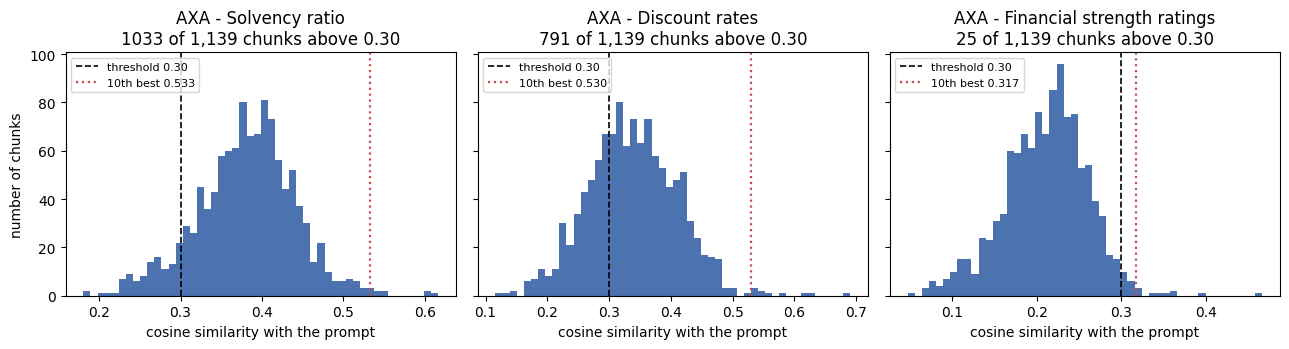

In [15]:
COMPANY_ROWS = {company: np.array([i for i, c in enumerate(CHUNKS) if c["company"] == company]) for company in COMPANIES}


def similarities(company: str, aspect: str) -> tuple[np.ndarray, np.ndarray]:
    # Cosine similarity between one aspect's prompt and every chunk of one report.
    rows = COMPANY_ROWS[company]
    vectors, query = CHUNK_VECTORS[rows], PROMPT_VECTORS[aspect]
    return rows, vectors @ query / (np.linalg.norm(vectors, axis=1) * np.linalg.norm(query))


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, aspect in zip(axes, ASPECT_ORDER):
    _, sims = similarities("AXA", aspect)
    tenth = np.sort(sims)[::-1][TOP_N - 1]
    ax.hist(sims, bins=50, color="#4C72B0")
    ax.axvline(THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"threshold {THRESHOLD:.2f}")
    ax.axvline(tenth, color="#C44E52", linestyle=":", linewidth=1.6, label=f"10th best {tenth:.3f}")
    ax.set_title(f"AXA - {ASPECTS[aspect]['label']}\n{(sims >= THRESHOLD).sum()} of {len(sims):,} chunks above {THRESHOLD:.2f}")
    ax.set_xlabel("cosine similarity with the prompt")
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("number of chunks")
fig.tight_layout()
plt.show()

The threshold does different work for the three prompts. For the solvency prompt, 1,033 of AXA's 1,139 chunks clear 0.30 — the whole report is about insurance finance — so the threshold filters almost nothing and the top-10 rule does all the selecting: the tenth-best chunk still scores 0.533. For the ratings prompt only 25 chunks clear it, and the tenth-best sits at 0.317, just above the line. At these settings the threshold is a safety net for questions a report cannot answer, not the main filter. In the ratings histogram, the lone chunk on the far right, at 0.466, is the one that holds the answer, as the next table shows.

### 4.2 The ten chunks that go into the prompt

The retrieval rule is the article's: rank the chunks by similarity, drop those below 0.30, keep the best ten. Here are the ten chunks retrieved for **AXA's financial strength ratings** — the combination section 6 will come back to.

In [16]:
def retrieve(company: str, aspect: str, top_n: int = TOP_N, threshold: float = THRESHOLD) -> list[dict]:
    # The article's retrieval rule: the top_n most similar chunks among those at or above the threshold.
    rows, sims = similarities(company, aspect)
    ranked = [(rows[i], float(sims[i])) for i in np.argsort(-sims) if sims[i] >= threshold]
    return [{**CHUNKS[row], "similarity": sim} for row, sim in ranked[:top_n]]


def retrieval_table(chunks: list[dict], preview: int = 110) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "rank": rank,
                "chunk": chunk["chunk_id"],
                "similarity": round(chunk["similarity"], 3),
                "PDF page": chunk["pages"],
                "preview": " ".join(chunk["text"].split())[:preview] + "...",
            }
            for rank, chunk in enumerate(chunks, start=1)
        ]
    ).set_index("rank")


retrieval_table(retrieve("AXA", "financial_strength_ratings"))

,chunk,similarity,PDF page,preview
rank,,,,
1,AXA-0024,0.466,21,he relevant ratings for the Company and its principal insurance subsidiaries were as follows: Agency Date of l...
2,AXA-0025,0.396,21-22,d to or intended for use or distribution to India‑based clients or users and its distribution to Indian reside...
3,AXA-0023,0.364,20-21,"ragraph 2° of Article 158.3 of the French General Tax Code (i.e., €0.62 per share for fiscal year 2021, €0.68 ..."
4,AXA-0620,0.358,304-305,"y and credit capacity of issuers, including the Company. The Group needs liquidity to pay our operating expens..."
5,AXA-0719,0.356,341,which the AXA Group manages limited business (not in the top 50) and reinsurers not rated by the main rating a...
6,AXA-0621,0.344,305,"they may change or withdraw their ratings at any time, based on relevant factors that may not be entirely with..."
7,AXA-0718,0.341,340-341,"k. rules on derivative contracts (ISDA, CSA); ● mandatory collateralization; ● a list of authorized counterpar..."
8,AXA-0576,0.323,285-286,es may indirectly result in negative impacts on biodiversity and ecosystems (“Nature and Ecosystems”) I- I- Ci...
9,AXA-0657,0.320,316-317,iods. AXA | Universal Registration Document 2025 314 Risk factors and risk management 5.1 Risk factors Capital...


Rank 1, at 0.466, is AXA-0024 — the ratings table itself, the chunk printed in section 3.3. Rank 3 is the chunk before it, which carries the table's column headings, and rank 2 the chunk after it. The rest are about ratings in general: risk factors on what a downgrade would mean, counterparty limits by rating, reinsurers without a rating — and, at rank 8, a passage on biodiversity. That is normal. The model receives the evidence together with some noise, and part of Stage 3's job is to ignore the noise. Note, too, how modest the best similarity is: it is the ranking, not the absolute value, that does the work.

Retrieval is computed **once** for all nine company–aspect pairs and kept in `RETRIEVED`. Everything that follows — the walkthrough and the benchmark — hands the models exactly the same evidence, so that differences between models are differences in generation, not in retrieval.

In [17]:
RETRIEVED = {(company, aspect): retrieve(company, aspect) for company in COMPANIES for aspect in ASPECT_ORDER}

pd.DataFrame(
    [
        {
            "company": company,
            "aspect": ASPECTS[aspect]["label"],
            f"chunks at or above {THRESHOLD:.2f}": int((similarities(company, aspect)[1] >= THRESHOLD).sum()),
            "retrieved": len(chunks),
            "best similarity": round(chunks[0]["similarity"], 3),
            "10th similarity": round(chunks[-1]["similarity"], 3),
            "PDF pages of the retrieved chunks": ", ".join(sorted({c["pages"] for c in chunks}, key=lambda p: tuple(int(x) for x in p.split("-")))),
        }
        for (company, aspect), chunks in RETRIEVED.items()
    ]
)

,company,aspect,chunks at or above 0.30,retrieved,best similarity,10th similarity,PDF pages of the retrieved chunks
0,AXA,Solvency ratio,1033,10,0.617,0.533,"49, 50, 331-332, 332-333, 333, 516-517, 517, 517-518, 518"
1,AXA,Discount rates,791,10,0.690,0.530,"30, 30-31, 375, 454, 454-455, 455, 457, 457-458, 485-487"
2,AXA,Financial strength ratings,25,10,0.466,0.317,"20-21, 21, 21-22, 151-152, 285-286, 304-305, 305, 316-317, 340-341, 341"
3,Generali,Solvency ratio,814,10,0.617,0.547,"173, 173-174, 176, 177-178, 178, 179-180, 181, 181-182, 182"
4,Generali,Discount rates,637,10,0.637,0.508,"238, 238-239, 239, 239-240, 273-274, 303-304, 305-306, 328-329, 336-337, 338-340"
5,Generali,Financial strength ratings,14,10,0.349,0.305,"19-20, 20, 82, 174-175, 185, 186-187, 241-242, 338-340, 340"
6,Zurich,Solvency ratio,711,10,0.685,0.567,"227-228, 231-232, 232, 232-233, 233-234, 234, 234-235, 235-236, 242, 294"
7,Zurich,Discount rates,542,10,0.623,0.515,"283, 283-284, 294, 301, 314, 337-338, 352-353, 362-363, 363-364, 374-375"
8,Zurich,Financial strength ratings,51,10,0.477,0.329,"33-34, 227-228, 232-233, 234-235, 235-236, 235-237, 246-247, 247, 424-425"


### 4.3 The augmented prompt, exactly as it is sent

The final step of Stage 2 is plain string formatting: the instruction, some guidance and the ten retrieved chunks are pasted into one message. The template is the research notebook's. Each chunk is labelled with its rank, its identifier and its similarity, so that anyone reading the prompt — or the audit file — can trace every passage back to the report.

Below is the complete prompt for AXA's ratings: the system prompt, which the API receives as `instructions`, followed by the user message. Nothing is abbreviated; this is precisely the text the model reads. Scroll through it once: this is all that RAG adds to an ordinary API call.

In [18]:
USER_TEMPLATE = """
Company: {company}
Target topic: {topic}

Extraction instruction:
{extraction_prompt}

Additional guidance:
- Use only the retrieved context below.
- If the information is not clearly stated, do not guess.
- Return the requested schema only.

Retrieved context:
{context}
""".strip()


def render_context(chunks: list[dict]) -> str:
    # The retrieved chunks as one readable block, each with its rank, identifier and similarity.
    blocks = []
    for rank, chunk in enumerate(chunks, start=1):
        blocks.append(
            f"[Context {rank}]\n"
            f"Company: {chunk['company']}\n"
            f"Chunk ID: {chunk['chunk_id']}\n"
            f"Similarity: {chunk['similarity']:.3f}\n"
            f"Text:\n{chunk['text']}"
        )
    return "\n\n".join(blocks)


def build_user_message(company: str, aspect: str) -> str:
    return USER_TEMPLATE.format(
        company=company,
        topic=ASPECTS[aspect]["title"],
        extraction_prompt=ASPECTS[aspect]["prompt"],
        context=render_context(RETRIEVED[(company, aspect)]),
    )


example_message = build_user_message("AXA", "financial_strength_ratings")
print("=" * 42, "instructions (system prompt)", "=" * 42)
print(SYSTEM_PROMPT)
print("=" * 47, "input (user message)", "=" * 47)
print(example_message)

========================================== instructions (system prompt) ==========================================
You are an AI assistant specialized in extracting and structuring key financial
and risk insights from annual reports of European insurance companies. Use RAG
to retrieve precise text segments and apply Structured Outputs to format data
consistently. Identify and extract regulatory ratios, discount rates, and cyber
risk strategies with exact numerical formats and contextual clarity. Ensure all
outputs follow the specified schema for seamless integration into actuarial
workflows and to support robust comparative analysis.
=============================================== input (user message) ===============================================
Company: AXA
Target topic: Insurance financial strength ratings by agency

Extraction instruction:
Extract insurer financial strength ratings (IFSR) as a list of entries with rater (e.g., AM Best, Fitch, Moody's, and S&P), rating, and outloo

That is the whole trick. Before the next section sends it, count what it costs: the tokeniser of the current OpenAI models (`o200k_base`, as in `01_llm_basics`) tells us how many input tokens this prompt is.

In [19]:
encoding = tiktoken.get_encoding("o200k_base")
prompt_tokens = len(encoding.encode(SYSTEM_PROMPT)) + len(encoding.encode(example_message))
price_in = PRICES_USD_PER_MTOK[MODEL][0]

print(f"Characters    : {len(SYSTEM_PROMPT) + len(example_message):,}")
print(f"Input tokens  : about {prompt_tokens:,} (counted locally; the API reports the exact figure)")
print(f"Input cost    : about USD {prompt_tokens * price_in / 1e6:.5f} on {MODEL}")
print(f"For comparison, the whole AXA report is about {len(encoding.encode(DOCUMENTS['AXA'][0])):,} tokens.")

Characters    : 21,677
Input tokens  : about 5,185 (counted locally; the API reports the exact figure)
Input cost    : about USD 0.00052 on gpt-6-luna


For comparison, the whole AXA report is about 469,907 tokens.


---

## 5 Stage 3: response generation

### Why it matters for actuaries

A comparison table needs a number in every cell, not three paragraphs of prose. Stage 3 sends the augmented prompt together with a **schema**, and the provider constrains the answer to fit it — the structured outputs of `02_llm_techniques`, now fed with retrieved evidence. What comes back is a validated Python object that drops straight into a table, a chart or a scoring function.

### 5.1 The three schemas

These are the article's Pydantic schemas, word for word, one per aspect: a number with a label, a list of (duration, rate) points, and a list of (rater, rating, outlook) records. `Literal` pins a field to the values listed; `Optional` allows the model to return `null` when the report gives no outlook.

The research notebook that produced the article's numbers used a tighter ratings schema than the one the article prints: a fixed list of agency names and outlooks, and a description for every field. Section 7.4 tries it. Here we keep the article's printed version and let the scoring rules in section 6 absorb harmless spelling variants such as "S&P Global Ratings" for "S&P".

In [20]:
# Solvency capital ratio schema: percentage and regulatory framework
class SolvencyResult(BaseModel):
    capital_ratio: int          # solvency ratio in %
    regulatory_framework: Literal["Solvency II", "SST"]

# Discount rate for a specific duration
class DiscountRatePoint(BaseModel):
    duration_year: int            # duration in years
    discount_rate_percent: float  # rate in percentage (e.g., 2.47)

# Aggregate discount rates across durations
class DiscountCurveResult(BaseModel):
    currency: Literal["EUR"]
    rates: List[DiscountRatePoint]  # list by duration

# Individual financial strength rating entry
class FinancialStrengthRating(BaseModel):
    rater: str                  # e.g., "S&P Global Ratings", "Moody's"
    rating: str                 # e.g., "AA-", "Aa3", "A+ Superior"
    outlook: Optional[str]      # e.g., "Stable", "Positive"

# Aggregate financial strength ratings
class FinancialStrengthRatingsResult(BaseModel):
    ratings: List[FinancialStrengthRating]


SCHEMAS = {
    "solvency_ratio": SolvencyResult,
    "discount_rates": DiscountCurveResult,
    "financial_strength_ratings": FinancialStrengthRatingsResult,
}

for aspect, schema in SCHEMAS.items():
    print(f"{ASPECTS[aspect]['label']:<27} -> {schema.__name__}({', '.join(schema.model_fields)})")

Solvency ratio              -> SolvencyResult(capital_ratio, regulatory_framework)
Discount rates              -> DiscountCurveResult(currency, rates)
Financial strength ratings  -> FinancialStrengthRatingsResult(ratings)


The model never sees these Python classes. What travels with the request is the **JSON schema** that Pydantic derives from them — here is the one for the ratings. This is the contract the provider enforces: the answer must be an object with a list called `ratings`, each entry with exactly these three fields.

In [21]:
print(json.dumps(FinancialStrengthRatingsResult.model_json_schema(), indent=2))

{
  "$defs": {
    "FinancialStrengthRating": {
      "properties": {
        "rater": {
          "title": "Rater",
          "type": "string"
        },
        "rating": {
          "title": "Rating",
          "type": "string"
        },
        "outlook": {
          "anyOf": [
            {
              "type": "string"
            },
            {
              "type": "null"
            }
          ],
          "title": "Outlook"
        }
      },
      "required": [
        "rater",
        "rating",
        "outlook"
      ],
      "title": "FinancialStrengthRating",
      "type": "object"
    }
  },
  "properties": {
    "ratings": {
      "items": {
        "$ref": "#/$defs/FinancialStrengthRating"
      },
      "title": "Ratings",
      "type": "array"
    }
  },
  "required": [
    "ratings"
  ],
  "title": "FinancialStrengthRatingsResult",
  "type": "object"
}


### 5.2 One call, shown in full

`extract()` is the whole of Stage 3: the system prompt goes in as `instructions`, the augmented user message from section 4.3 as `input`, and the schema as `text_format` — exactly the `client.responses.parse` call of `02_llm_techniques`. It records the tokens and the cost of every call in the ledger, and it never lets a failed call stop the notebook. It also tells two kinds of failure apart: an **API error** (no key, an exhausted quota, the rate limit, the network), where the question never reached the model, and a **failed answer**, where the model replied but produced nothing usable. Both are scored as fails later, but only the second says anything about the model.

**About `temperature`.** The GPT-5.4 models accept `temperature` only at reasoning effort "none", which is their default; at effort "low" or higher they reject it with an error. GPT-6 Luna, too, accepts it only at effort "none", which is how Case Study 1 uses it; this notebook leaves Luna at its default effort, "medium", at which it rejects the parameter and manages its own sampling. `01_llm_basics` and `02_llm_techniques` never set it on an API model. The article, however, ran every model at temperature 0, so for the two GPT-5.4 models in the benchmark of section 7 we pass `temperature=0` together with an explicit reasoning effort of "none", to reproduce the article's run conditions. That is the only reason the parameter appears here; GPT-6 Luna gets neither.

In [22]:
def usage_counts(usage) -> tuple[int, int, int, int, int]:
    # (input, cached input, cache-write, output, reasoning) tokens from a Responses API usage object.
    # cache_write_tokens is a typed field in openai 3.x and an untyped extra one in 2.x: getattr reads both, 0 if absent.
    input_details = getattr(usage, "input_tokens_details", None)
    output_details = getattr(usage, "output_tokens_details", None)
    cached = (getattr(input_details, "cached_tokens", 0) or 0) if input_details else 0
    cache_write = (getattr(input_details, "cache_write_tokens", 0) or 0) if input_details else 0
    reasoning = (getattr(output_details, "reasoning_tokens", 0) or 0) if output_details else 0
    return usage.input_tokens, cached, cache_write, usage.output_tokens, reasoning


def extract(company: str, aspect: str, model: str = MODEL, purpose: str = "walkthrough", schema=None) -> dict:
    # Stage 3 for one company and one aspect: the augmented prompt in, a validated Pydantic object out.
    require_client()
    schema = schema or SCHEMAS[aspect]
    message = build_user_message(company, aspect)
    record = {"company": company, "aspect": aspect, "model": model, "parsed": None, "raw_json": None,
              "error": None, "api_error": None, "input_tokens": 0, "cached_tokens": 0, "cache_write_tokens": 0,
              "output_tokens": 0, "reasoning_tokens": 0, "cost_usd": 0.0, "cost_usd_cold_run": 0.0}
    started = time.time()
    try:
        response = client.responses.parse(
            model=model,
            instructions=SYSTEM_PROMPT,
            input=message,
            text_format=schema,
            **SAMPLING_OPTIONS.get(model, {}),
        )
    except APIError as exc:  # the question never reached the model: key, quota, rate limit or network
        record["error"] = record["api_error"] = f"{type(exc).__name__}: {str(exc)[:200]}"
    except Exception as exc:  # the model replied, but its answer could not be used (for example, cut off)
        record["error"] = f"{type(exc).__name__}: {str(exc)[:200]}"
    else:
        tokens_in, cached, cache_write, tokens_out, reasoning = usage_counts(response.usage)
        prompt_key = hashlib.sha256(f"{model}|{schema.__name__}|{message}".encode("utf-8")).hexdigest()
        row = log_usage(model, purpose, tokens_in, cached, tokens_out, prompt_key=prompt_key,
                        cache_write_tokens=cache_write)
        record.update(
            parsed=response.output_parsed,
            raw_json=response.output_text,
            input_tokens=tokens_in,
            cached_tokens=cached,
            cache_write_tokens=cache_write,
            output_tokens=tokens_out,
            reasoning_tokens=reasoning,
            cost_usd=row["cost_usd"],
            cost_usd_cold_run=row["cost_usd_cold_run"],
        )
        if response.output_parsed is None:
            record["error"] = "no parsed answer - the model may have refused"
    record["seconds"] = round(time.time() - started, 1)
    return record


def report_api_errors(records: list[dict], where: str) -> None:
    # One line that separates infrastructure trouble from wrong answers.
    failed = [r for r in records if r.get("api_error")]
    if failed:
        print(f"[ATTENTION] {len(failed)} of {len(records)} calls in {where} failed with an API error, not a wrong answer "
              f"(first: {failed[0]['api_error'][:100]}). They are counted separately; re-run the cell once the problem has gone.")
    else:
        print(f"[PASS] All {len(records)} calls in {where} reached the model: any fail below is an answer, not an API error.")


single = extract("AXA", "financial_strength_ratings")

print(f"Model: {single['model']}   Company: {single['company']}   Aspect: {single['aspect']}")
print(f"Error: {single['error']}")
print()
print("Raw JSON, exactly as the model returned it:")
print(single["raw_json"])
print()
print("The same answer after Pydantic has parsed and validated it:")
print(repr(single["parsed"]))
print()
print(f"Tokens: {single['input_tokens']:,} in ({single['cached_tokens']:,} of them cached), "
      f"{single['output_tokens']:,} out ({single['reasoning_tokens']:,} of them reasoning)")
print(f"Cost  : USD {single['cost_usd']:.5f} in this run; USD {single['cost_usd_cold_run']:.5f} on a cold first run"
      f"      Time: {single['seconds']} seconds")

Model: gpt-6-luna   Company: AXA   Aspect: financial_strength_ratings
Error: None

Raw JSON, exactly as the model returned it:
{"ratings":[{"rater":"S&P Global Ratings","rating":"AA-","outlook":"Positive"},{"rater":"Moody’s Investors Service","rating":"Aa2","outlook":"Stable"},{"rater":"A.M. Best Rating Services","rating":"aa Superior","outlook":"Stable"}]}

The same answer after Pydantic has parsed and validated it:
FinancialStrengthRatingsResult(ratings=[FinancialStrengthRating(rater='S&P Global Ratings', rating='AA-', outlook='Positive'), FinancialStrengthRating(rater='Moody’s Investors Service', rating='Aa2', outlook='Stable'), FinancialStrengthRating(rater='A.M. Best Rating Services', rating='aa Superior', outlook='Stable')])

Tokens: 5,310 in (5,307 of them cached), 1,566 out (1,492 of them reasoning)
Cost  : USD 0.00084 in this run; USD 0.00131 on a cold first run      Time: 14.0 seconds


The answer has exactly the shape the schema demands — three entries, each with a rater, a rating and an outlook — and the three outlooks are right. So are S&P's AA- and Moody's Aa2. **AM Best's rating is wrong**: "aa Superior" is not a financial strength rating at all. The report's ratings table has one column for **AXA SA**, the holding company, one for **AXA's principal insurance subsidiaries**, and further columns for the credit ratings of AXA's debt; "aa Superior" is AM Best's rating of AXA's senior debt. The chunk printed in section 3.3 shows what is left of that layout once the PDF has been flattened into text, and section 6 comes back to it. A schema guarantees the shape of an answer, never its content.

Two further details. The model spent 1,492 of its 1,566 output tokens reasoning before it answered — it evidently found the table hard. And 5,307 of its 5,310 input tokens were billed at the cached rate, a tenth of the price, because this exact prompt had been sent shortly before, in a previous run of this notebook. On your own first run nothing is cached, and the call costs what the cold-run figure says: USD 0.00131 instead of USD 0.00084.

The model is not deterministic either: section 5.3 sends the same prompt again, and gets a different answer.

### 5.3 All three companies, all three aspects

Now the full market comparison on GPT-6 Luna: nine calls, one per company and aspect, sent in parallel because none of them depends on another.

In [23]:
JOBS = [(company, aspect) for company in COMPANIES for aspect in ASPECT_ORDER]

started = time.time()
with ThreadPoolExecutor(max_workers=len(JOBS)) as pool:
    WALKTHROUGH = list(pool.map(lambda job: extract(*job), JOBS))
RESULTS = {(record["company"], record["aspect"]): record for record in WALKTHROUGH}

print(f"{len(WALKTHROUGH)} extractions on {MODEL} in {time.time() - started:.0f} seconds: "
      f"USD {sum(r['cost_usd'] for r in WALKTHROUGH):.4f} in this run, "
      f"USD {sum(r['cost_usd_cold_run'] for r in WALKTHROUGH):.4f} estimated for a cold first run.")
report_api_errors(WALKTHROUGH, "section 5.3")
pd.DataFrame(
    [
        {
            "company": r["company"],
            "aspect": ASPECTS[r["aspect"]]["label"],
            "status": "ok" if r["error"] is None else r["error"],
            "input tokens": r["input_tokens"],
            "cached tokens": r["cached_tokens"],
            "output tokens": r["output_tokens"],
            "cost (USD)": round(r["cost_usd"], 5),
            "cold run (USD)": round(r["cost_usd_cold_run"], 5),
            "seconds": r["seconds"],
        }
        for r in WALKTHROUGH
    ]
)

9 extractions on gpt-6-luna in 12 seconds: USD 0.0053 in this run, USD 0.0058 estimated for a cold first run.
[PASS] All 9 calls in section 5.3 reached the model: any fail below is an answer, not an API error.


,company,aspect,status,input tokens,cached tokens,output tokens,cost (USD),cold run (USD),seconds
0,AXA,Solvency ratio,ok,4947,0,25,0.00051,0.00051,1.4
1,AXA,Discount rates,ok,6721,0,205,0.00077,0.00077,2.9
2,AXA,Financial strength ratings,ok,5310,5307,1178,0.00064,0.00064,11.7
3,Generali,Solvency ratio,ok,4953,0,52,0.00052,0.00052,1.8
4,Generali,Discount rates,ok,8073,0,311,0.00096,0.00096,3.4
5,Generali,Financial strength ratings,ok,4992,0,118,0.00056,0.00056,2.4
6,Zurich,Solvency ratio,ok,5010,0,47,0.00052,0.00052,2.1
7,Zurich,Discount rates,ok,6234,0,155,0.00070,0.00070,2.4
8,Zurich,Financial strength ratings,ok,5397,5394,145,0.00013,0.00061,3.1


From here on nothing calls a model: the answers are data, and ordinary `pandas` turns them into the comparison a reader actually wants. First the solvency position of the three groups, side by side.

In [24]:
def parsed_or_none(company: str, aspect: str):
    return RESULTS[(company, aspect)]["parsed"]


solvency_table = pd.DataFrame(
    [
        {
            "company": company,
            "solvency ratio (%)": parsed.capital_ratio if parsed else None,
            "regulatory framework": parsed.regulatory_framework if parsed else "no answer",
        }
        for company in COMPANIES
        for parsed in [parsed_or_none(company, "solvency_ratio")]
    ]
).set_index("company")
solvency_table

,solvency ratio (%),regulatory framework
company,,
AXA,224,Solvency II
Generali,219,Solvency II
Zurich,259,SST


The EUR discount curves. Each group publishes a different set of durations, so the table has gaps — shown as a dash, exactly as in the article's table.

In [25]:
curves, clashes = {}, {}
for company in COMPANIES:
    parsed = parsed_or_none(company, "discount_rates")
    if parsed:
        values = {}
        for point in parsed.rates:
            values.setdefault(point.duration_year, []).append(point.discount_rate_percent)
        curves[company] = {duration: rates[0] for duration, rates in values.items()}
        clashes.update({(company, d): rates for d, rates in values.items() if len(set(rates)) > 1})

if clashes:  # a model that mixes two curves returns some durations twice - show that rather than hide it
    print(f"[ATTENTION] Durations returned twice with different rates (the first one is shown): {clashes}")

curve_table = pd.DataFrame(curves).sort_index()
curve_table.index.name = "duration (years)"
curve_table.map(lambda value: "–" if pd.isna(value) else f"{value:.2f}")

,AXA,Generali,Zurich
duration (years),,,
1,2.40,2.22,2.08
2,2.50,2.30,–
3,2.60,2.42,–
4,–,2.53,–
5,2.80,2.62,2.48
6,–,2.70,–
7,3.00,2.79,–
8,–,2.86,–
9,–,2.93,–


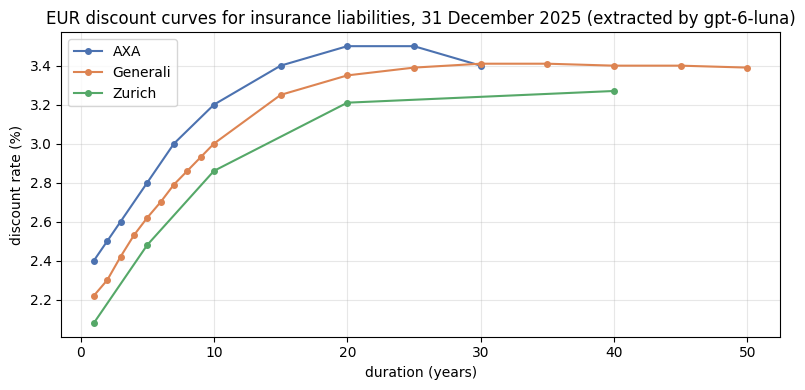

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
for company, colour in zip(curve_table.columns, ["#4C72B0", "#DD8452", "#55A868"]):
    points = curve_table[company].dropna()
    ax.plot(points.index, points.values, marker="o", markersize=4, label=company, color=colour)
ax.set_title(f"EUR discount curves for insurance liabilities, 31 December 2025 (extracted by {MODEL})")
ax.set_xlabel("duration (years)")
ax.set_ylabel("discount rate (%)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

And the financial strength ratings, one row per agency, exactly as the model wrote them.

In [27]:
pd.DataFrame(
    [
        {"company": company, "rater": entry.rater, "rating": entry.rating, "outlook": entry.outlook}
        for company in COMPANIES
        if parsed_or_none(company, "financial_strength_ratings")
        for entry in parsed_or_none(company, "financial_strength_ratings").ratings
    ]
).set_index("company")

,rater,rating,outlook
company,,,
AXA,S&P Global Ratings,AA-,Positive
AXA,Moody’s Investors Service,Aa2,Stable
AXA,A.M. Best Rating Services,A+ Superior,Stable
Generali,Moody's,A2,stable
Generali,AM Best,A+,stable
Generali,Fitch,AA-,stable
Zurich,S&P Global Ratings,AA,stable
Zurich,Moody's,Aa2,stable
Zurich,AM Best,A+ (Superior),stable


Three reports, nine answers, about twelve seconds and half a US cent: USD 0.0053 in the saved run, USD 0.0058 on a cold first run. The cached-tokens column shows why the two differ. The AXA ratings prompt was billed almost entirely at the cached rate because section 5.2 had just sent it — that will happen on your first run too. The Zurich ratings prompt was cached because a previous run of this notebook had sent it shortly before — that will not.

The solvency ratios — 224% and 219% under Solvency II, 259% under the SST — and the three discount curves look plausible at a glance, and the chart has the expected shape: rising steeply over the first ten to twenty years and flattening at the long end. AXA's AM Best rating now reads "A+ Superior": the same prompt as in section 5.2, a different — and this time correct — answer.

The ratings table also shows how much formatting freedom the article's schema leaves: "A.M. Best Rating Services" next to "AM Best", "A+ (Superior)" next to "A+ Superior", outlooks in upper and lower case. None of that troubles a human reader, but code building a comparison table would treat every spelling as a different value — which is why the scoring in section 6 normalises them first. Plausible is not the same as right; section 6 checks every field.

---

## 6 Checking the answers

### Why it matters for actuaries

A table that looks plausible is not a table that is right. Before anyone relies on an extraction, it has to be checked against values somebody has verified — and the check has to be deterministic, so that it gives the same verdict every time it is run.

### 6.1 The ground truth

The reference values below are **the article's ground truth**, extracted by hand by its authors from the same 2025 annual reports (the article's three ground-truth tables). Nothing in this notebook produced them. In total there are 45 fields: 3 solvency ratios, each with its framework label; 33 discount-rate points (10 for AXA, 18 for Generali, 5 for Zurich); and 9 rating entries.

In [28]:
# The article's ground truth (Hatzesberger & Nonneman 2026, its ground-truth tables), extracted by hand by its authors.
GROUND_TRUTH = {
    "AXA": {
        "solvency_ratio": {"capital_ratio": 224, "regulatory_framework": "Solvency II"},
        "discount_rates": {1: 2.40, 2: 2.50, 3: 2.60, 5: 2.80, 7: 3.00, 10: 3.20, 15: 3.40, 20: 3.50, 25: 3.50, 30: 3.40},
        "financial_strength_ratings": [
            {"rater": "S&P", "rating": "AA-", "outlook": "Positive"},
            {"rater": "Moody's", "rating": "Aa2", "outlook": "Stable"},
            {"rater": "AM Best", "rating": "A+ Superior", "outlook": "Stable"},
        ],
    },
    "Generali": {
        "solvency_ratio": {"capital_ratio": 219, "regulatory_framework": "Solvency II"},
        "discount_rates": {1: 2.22, 2: 2.30, 3: 2.42, 4: 2.53, 5: 2.62, 6: 2.70, 7: 2.79, 8: 2.86, 9: 2.93, 10: 3.00,
                           15: 3.25, 20: 3.35, 25: 3.39, 30: 3.41, 35: 3.41, 40: 3.40, 45: 3.40, 50: 3.39},
        "financial_strength_ratings": [
            {"rater": "Moody's", "rating": "A2", "outlook": "Stable"},
            {"rater": "Fitch", "rating": "AA-", "outlook": "Stable"},
            {"rater": "AM Best", "rating": "A+", "outlook": "Stable"},
        ],
    },
    "Zurich": {
        "solvency_ratio": {"capital_ratio": 259, "regulatory_framework": "SST"},
        "discount_rates": {1: 2.08, 5: 2.48, 10: 2.86, 20: 3.21, 40: 3.27},
        "financial_strength_ratings": [
            {"rater": "S&P", "rating": "AA", "outlook": "Stable"},
            {"rater": "Moody's", "rating": "Aa2", "outlook": "Stable"},
            {"rater": "AM Best", "rating": "A+ Superior", "outlook": "Stable"},
        ],
    },
}

n_fields = sum(1 + len(truth["discount_rates"]) + len(truth["financial_strength_ratings"]) for truth in GROUND_TRUTH.values())
print(f"Ground truth: {n_fields} fields.")

display(pd.DataFrame(
    [{"company": c, "capital ratio (%)": t["solvency_ratio"]["capital_ratio"], "framework": t["solvency_ratio"]["regulatory_framework"]}
     for c, t in GROUND_TRUTH.items()]
).set_index("company"))

truth_curves = pd.DataFrame({c: t["discount_rates"] for c, t in GROUND_TRUTH.items()}).sort_index()
truth_curves.index.name = "duration (years)"
display(truth_curves.map(lambda value: "–" if pd.isna(value) else f"{value:.2f}"))

display(pd.DataFrame(
    [{"company": c, **entry} for c, t in GROUND_TRUTH.items() for entry in t["financial_strength_ratings"]]
).set_index("company"))

Ground truth: 45 fields.


,capital ratio (%),framework
company,,
AXA,224,Solvency II
Generali,219,Solvency II
Zurich,259,SST


,AXA,Generali,Zurich
duration (years),,,
1,2.40,2.22,2.08
2,2.50,2.30,–
3,2.60,2.42,–
4,–,2.53,–
5,2.80,2.62,2.48
6,–,2.70,–
7,3.00,2.79,–
8,–,2.86,–
9,–,2.93,–


,rater,rating,outlook
company,,,
AXA,S&P,AA-,Positive
AXA,Moody's,Aa2,Stable
AXA,AM Best,A+ Superior,Stable
Generali,Moody's,A2,Stable
Generali,Fitch,AA-,Stable
Generali,AM Best,A+,Stable
Zurich,S&P,AA,Stable
Zurich,Moody's,Aa2,Stable
Zurich,AM Best,A+ Superior,Stable


### 6.2 The scoring rules

The rules are the article's, as its research notebook implements them, and each extraction scores **pass or fail** — no partial credit:

- **Solvency ratio** — the integer ratio and the framework label must both be exactly right.
- **Discount rates** — every duration in the ground truth must be present, with the right rate. Rates are compared after rounding to two decimals, so a value that rounds to the published figure passes (`2.4` and `2.40` alike); there is no wider tolerance band. A duration returned twice with different rates fails. Durations the model adds beyond the ground truth are not scored.
- **Financial strength ratings** — a normalised set comparison. Agency names are mapped to canonical forms ("S&P Global Ratings", "Standard & Poor's" and "Standard and Poor's" all become "S&P"), ratings are upper-cased with brackets and spaces removed (so "A+ (Superior)" equals "A+ Superior"), and an outlook becomes the first of "Positive", "Stable" or "Negative" that it mentions. The normalised set must equal the ground-truth set. The article requires every ground-truth entry to be matched; its research notebook, which produced the article's numbers, also fails an extra agency or the same agency twice, and so do we. We also treat the typographic hyphens the PDFs use (for example `‑`, a non-breaking hyphen) as an ordinary `-`.

Why so strict? A solvency ratio, a discount curve or a rating is only usable in a market comparison if it reproduces the published figure; an approximately right value would travel silently into the analysis. A strict rule mirrors the acceptance decision an actuary would make.

Each field also gets a coarse **evidence check**: does the expected value appear anywhere in the ten chunks the model was given? If it does not, a wrong answer is a **retrieval failure** — the evidence never reached the model. If it does, a wrong answer is most likely a **generation failure** — the model had the evidence and misread it. The check is deliberately simple (a text search), so a "yes" means the value is somewhere in the context, not necessarily in the right table.

An extraction that produced no answer at all still gets a row for every ground-truth field, marked "no answer", so the count below is always out of 45. The cell ends by showing the normalisation at work.

In [29]:
DASHES = str.maketrans({c: "-" for c in "\u2010\u2011\u2012\u2013\u2014\u2212"})  # typographic hyphens and dashes


def canonical_rater(name: str) -> str:
    # Map the many spellings of an agency's name to one canonical form.
    compact = re.sub(r"[^a-z0-9]+", "", name.casefold())
    if "moodys" in compact:
        return "Moody's"
    if compact.startswith("sp") or any(form in compact for form in ("standardpoors", "standardandpoors", "spglobal")):
        return "S&P"
    if "ambest" in compact:
        return "AM Best"
    if "fitch" in compact:
        return "Fitch"
    return "Other"


def normalise_rating(value: str | None) -> str | None:
    # Upper-case, brackets and spaces removed, typographic hyphens made plain: "A+ (Superior)" -> "A+SUPERIOR".
    if value is None:
        return None
    text = value.translate(DASHES).replace("(", " ").replace(")", " ")
    return "".join(text.split()).upper() or None


def normalise_outlook(value: str | None) -> str | None:
    # Title-cased canonical outlook: the first of positive, stable or negative that the text mentions, or None.
    if value is None:
        return None
    lowered = value.casefold()
    found = [(lowered.find(word), word) for word in ("positive", "stable", "negative") if word in lowered]
    return min(found)[1].title() if found else None


def normalise_entry(rater: str, rating: str | None, outlook: str | None) -> tuple:
    return canonical_rater(rater), normalise_rating(rating), normalise_outlook(outlook)


def context_text(company: str, aspect: str) -> str:
    # Everything the model was shown for this company and aspect, whitespace and hyphens normalised.
    return " ".join(" ".join(c["text"] for c in RETRIEVED[(company, aspect)]).translate(DASHES).split())


def percentage_in(value: float, text: str) -> bool:
    # Does a percentage such as 2.40 appear in the text, written as 2.40% or 2.4%?
    forms = {f"{value:.2f}", f"{value:.1f}" if round(value, 1) == round(value, 2) else f"{value:.2f}"}
    return any(re.search(rf"(?<![\d.]){re.escape(form)}\s?%", text) for form in forms)


def rating_in(rating: str, text: str) -> bool:
    # Does a rating such as "A+ Superior" appear in the text, also written as "A+ (Superior)"?
    tokens = rating.translate(DASHES).replace("(", " ").replace(")", " ").split()
    body = r"[\s()]*".join(re.escape(token) for token in tokens)
    return re.search(rf"(?<![\w+-]){body}(?![\w+-])", text) is not None


def solvency_in(ratio: int, text: str) -> bool:
    return re.search(rf"(?<!\d){ratio}\s?%", text) is not None


def score_solvency(parsed: SolvencyResult | None, truth: dict, context: str) -> tuple[bool, list[dict], str]:
    passed = parsed is not None and (parsed.capital_ratio, parsed.regulatory_framework) == (
        truth["capital_ratio"], truth["regulatory_framework"])
    field = {
        "field": "ratio and framework",
        "expected": f"{truth['capital_ratio']}% ({truth['regulatory_framework']})",
        "extracted": "no answer" if parsed is None else f"{parsed.capital_ratio}% ({parsed.regulatory_framework})",
        "match": passed,
        "in context": solvency_in(truth["capital_ratio"], context),
    }
    return passed, [field], "exact" if passed else "ratio or framework differs"


def score_discount_rates(parsed: DiscountCurveResult | None, truth: dict, context: str) -> tuple[bool, list[dict], str]:
    # Rates are compared after rounding to two decimals. A duration returned twice with different rates
    # (for instance from two currencies or two dates) fails rather than letting the last value win.
    predicted: dict[int, set] = {}
    for point in (parsed.rates if parsed is not None else []):
        predicted.setdefault(int(point.duration_year), set()).add(round(float(point.discount_rate_percent), 2))
    fields = []
    for duration, expected in truth.items():
        got = predicted.get(duration)
        extracted = "no answer" if parsed is None else "missing" if not got else " / ".join(f"{v:.2f}" for v in sorted(got))
        fields.append(
            {
                "field": f"{duration} years",
                "expected": f"{expected:.2f}",
                "extracted": extracted,
                "match": got == {round(expected, 2)},
                "in context": percentage_in(expected, context),
            }
        )
    hits = sum(f["match"] for f in fields)
    notes = [f"{hits} of {len(truth)} durations exact"]
    conflicting = sorted(d for d in truth if len(predicted.get(d, ())) > 1)
    if conflicting:
        notes.append(f"durations returned twice with different rates: {conflicting}")
    extra = sorted(set(predicted) - set(truth))
    if extra:
        notes.append(f"extra durations {extra} not scored")
    return hits == len(truth), fields, "; ".join(notes)


def score_ratings(parsed: FinancialStrengthRatingsResult | None, truth: list[dict], context: str) -> tuple[bool, list[dict], str]:
    predicted = [(normalise_entry(e.rater, e.rating, e.outlook), e) for e in (parsed.ratings if parsed is not None else [])]
    predicted_set = {entry for entry, _ in predicted}
    expected_set = {normalise_entry(**t) for t in truth}
    raters = [entry[0] for entry, _ in predicted]
    duplicates = sorted({r for r in raters if raters.count(r) > 1})
    fields = []
    for t in truth:
        expected = normalise_entry(**t)
        same_agency = [f"{e.rating} ({e.outlook})" for entry, e in predicted if entry[0] == expected[0]]
        fields.append(
            {
                "field": expected[0],
                "expected": f"{t['rating']} ({t['outlook']})",
                "extracted": "no answer" if parsed is None else "; ".join(same_agency) or "missing",
                "match": expected in predicted_set,
                "in context": rating_in(t["rating"], context),
            }
        )
    notes = [f"{len(predicted_set & expected_set)} of {len(expected_set)} entries match"]
    if predicted_set - expected_set:
        notes.append("unexpected: " + ", ".join(f"{r} {g} ({o})" for r, g, o in sorted(predicted_set - expected_set, key=str)))
    if duplicates:
        notes.append(f"duplicate agencies: {duplicates}")
    return predicted_set == expected_set and not duplicates, fields, "; ".join(notes)


SCORERS = {"solvency_ratio": score_solvency, "discount_rates": score_discount_rates, "financial_strength_ratings": score_ratings}


def evaluate(record: dict) -> tuple[bool, list[dict], str]:
    # Score one extraction against the ground truth: (passed, one row per ground-truth field, a short note).
    # An extraction without an answer still yields every field, marked "no answer", so the count stays at 45.
    company, aspect = record["company"], record["aspect"]
    passed, fields, note = SCORERS[aspect](record["parsed"], GROUND_TRUTH[company][aspect], context_text(company, aspect))
    if record["parsed"] is None:
        note = ("API error: " if record.get("api_error") else "no answer: ") + str(record["error"])
    return passed, fields, note


# The normalisation at work on a few spellings that occur in the reports and in model answers.
for name in ["S&P Global Ratings", "Standard & Poor's", "Standard and Poor's", "Moody\u2019s Investors Service", "A.M. Best Rating Services"]:
    print(f"{name:<28} -> {canonical_rater(name)}")
for rating in ["A+ (Superior)", "A+ Superior", "aa Superior", "AA\u2011"]:  # the last one ends in a non-breaking hyphen
    print(f"{rating:<28} -> {normalise_rating(rating)}")
for outlook in ["stable", "Negative (revised from Stable)"]:
    print(f"{outlook:<28} -> {normalise_outlook(outlook)}")

S&P Global Ratings           -> S&P
Standard & Poor's            -> S&P
Standard and Poor's          -> S&P
Moody’s Investors Service    -> Moody's
A.M. Best Rating Services    -> AM Best
A+ (Superior)                -> A+SUPERIOR
A+ Superior                  -> A+SUPERIOR
aa Superior                  -> AASUPERIOR
AA‑                          -> AA-
stable                       -> Stable
Negative (revised from Stable) -> Negative


### 6.3 How GPT-6 Luna did

First the verdict per company and aspect, then every one of the 45 fields.

In [30]:
field_rows, verdicts = [], []
for record in WALKTHROUGH:
    passed, fields, note = evaluate(record)
    label = ASPECTS[record["aspect"]]["label"]
    verdicts.append({"company": record["company"], "aspect": label, "passed": passed,
                     "fields matched": f"{sum(f['match'] for f in fields)} of {len(fields)}", "note": note})
    field_rows += [{"company": record["company"], "aspect": label, **field} for field in fields]

FIELDS = pd.DataFrame(field_rows)
display(pd.DataFrame(verdicts).set_index(["company", "aspect"]))
print(f"Aspects passed : {sum(v['passed'] for v in verdicts)} of {len(verdicts)}")
print(f"Fields matched : {FIELDS['match'].sum()} of {len(FIELDS)}")

passed fields matched                      note
company  aspect                                                                     
AXA      Solvency ratio                True         1 of 1                     exact
         Discount rates                True       10 of 10  10 of 10 durations exact
         Financial strength ratings    True         3 of 3      3 of 3 entries match
Generali Solvency ratio                True         1 of 1                     exact
         Discount rates                True       18 of 18  18 of 18 durations exact
         Financial strength ratings    True         3 of 3      3 of 3 entries match
Zurich   Solvency ratio                True         1 of 1                     exact
         Discount rates                True         5 of 5    5 of 5 durations exact
         Financial strength ratings    True         3 of 3      3 of 3 entries match

Aspects passed : 9 of 9
Fields matched : 45 of 45


In [31]:
pd.set_option("display.max_rows", 100)
FIELDS.set_index(["company", "aspect", "field"])

expected               extracted  match  in context
company  aspect                     field                                                                               
AXA      Solvency ratio             ratio and framework    224% (Solvency II)      224% (Solvency II)   True        True
         Discount rates             1 years                              2.40                    2.40   True        True
                                    2 years                              2.50                    2.50   True        True
                                    3 years                              2.60                    2.60   True        True
                                    5 years                              2.80                    2.80   True        True
                                    7 years                              3.00                    3.00   True        True
                                    10 years                             3.20                    3.20   True        True
                                    15 years                             3.40                    3.40   True        True
                                    20 years                             3.50                    3.50   True        True
                                    25 years                             3.50                    3.50   True        True
                                    30 years                             3.40                    3.40   True        True
         Financial strength ratings S&P                        AA- (Positive)          AA- (Positive)   True        True
                                    Moody's                      Aa2 (Stable)            Aa2 (Stable)   True        True
                                    AM Best              A+ Superior (Stable)    A+ Superior (Stable)   True        True
Generali Solvency ratio             ratio and framework    219% (Solvency II)      219% (Solvency II)   True        True
         Discount rates             1 years                              2.22                    2.22   True        True
                                    2 years                              2.30                    2.30   True        True
                                    3 years                              2.42                    2.42   True        True
                                    4 years                              2.53                    2.53   True        True
                                    5 years                              2.62                    2.62   True        True
                                    6 years                              2.70                    2.70   True        True
                                    7 years                              2.79                    2.79   True        True
                                    8 years                              2.86                    2.86   True        True
                                    9 years                              2.93                    2.93   True        True
                                    10 years                             3.00                    3.00   True        True
                                    15 years                             3.25                    3.25   True        True
                                    20 years                             3.35                    3.35   True        True
                                    25 years                             3.39                    3.39   True        True
                                    30 years                             3.41                    3.41   True        True
                                    35 years                             3.41                    3.41   True        True
                                    40 years                             3.40                    3.40   True        True
                                    45 years                             3.4

**A clean sweep — this time.** All 45 fields are right and all 9 aspects pass: the three solvency ratios; all 33 discount-rate points, including AXA's curve, which the report prints with one decimal (2.4%) in a table that also holds five other currencies and the previous year's rates; and all nine ratings. The evidence check confirms that every expected value was among the retrieved chunks, so there was no retrieval failure to find.

One run proves little, though. Section 5.2 sent the AXA ratings prompt once already and got "aa Superior" for AM Best, and section 7 repeats exactly this extraction three times per model, on exactly this retrieved evidence: AXA's ratings fail there again and again, and GPT-6 Luna itself returns "aa Superior" instead of "A+ Superior" in two of its three runs. "A+ Superior" is in the context every time: it stands in chunk AXA-0024, ranked first. By the taxonomy the article adopts — retrieval failures against generation failures — those are therefore **generation failures**: the model had the evidence and misread it. The passage below, printed exactly as the model receives it, shows why it is easy to misread.

In [32]:
# The ratings passage the model was given for AXA: the start of the table, from its best-ranked chunk.
axa_table = RETRIEVED[("AXA", "financial_strength_ratings")][0]["text"]
start = axa_table.find("Agency")
print(axa_table[start : axa_table.find("1.5.2")].strip())

Agency
Date of last review
AXA SA
Insurer financial strength ratings
AXA's credit ratings
AXA’s principal
insurance subsidiaries
Outlook
Senior
debt of the
Company
Short‑term
debt of the
Company
S&P Global Ratings
October 3, 2025
A+
AA-
Positive
A+
A‑1+
Moody’s Investors Service
October 8, 2025
Aa2
Aa2
Stable
Aa3
P‑1
A.M. Best Rating Services
October 9, 2025
A+ Superior
-
Stable
aa Superior
-


This is the table exactly as the model received it: every cell on its own line, in reading order. In the PDF it is a grid with a two-level header — the insurer financial strength ratings of **AXA SA** (the holding company) and of **AXA's principal insurance subsidiaries**, then the outlook, then **AXA's credit ratings** for its senior and short-term debt. So the AM Best row, "A+ Superior / - / Stable / aa Superior / -", says: A+ Superior is AXA SA's financial strength rating, the dash says there is none for the subsidiaries, and "aa Superior" is AM Best's rating of AXA's senior debt — a credit rating.

Two lessons follow.

- **The ground truth is a judgement, too.** It takes the subsidiaries' rating where there is one (S&P: AA-, not AXA SA's A+) and AXA SA's where there is not (AM Best: A+ Superior). This is the entity-level ambiguity the article describes — holding company or insurance subsidiaries — and a model can only resolve it consistently if the prompt says which convention to follow.
- **The failures are generation failures, but their root lies in Stage 1.** Flattening the table threw away the column structure the model needs to tell the columns apart. The taxonomy of retrieval and generation failures is useful; its boxes are not watertight.

---

## 7 A small benchmark

### Why it matters for actuaries

One run of one model proves little: the same prompt can give a different answer tomorrow, and a cheaper model may be good enough. The article therefore ran five models twenty times each. We run a small version of that in the room: **three models, three runs each**, on all three companies and aspects — 81 extractions. Retrieval was computed once in section 4, so every model sees exactly the same ten chunks; any difference is a difference in generation.

| Model | Identifier | Temperature |
| --- | --- | --- |
| GPT-6 Luna | `gpt-6-luna` (alias, no dated snapshot) | not sent — at its default effort, "medium", the model rejects it |
| GPT-5.4 mini | `gpt-5.4-mini-2026-03-17` | 0 at reasoning effort "none", as in the article |
| GPT-5.4 | `gpt-5.4-2026-03-05` | 0 at reasoning effort "none", as in the article |

The calls run in parallel, eight at a time. Most of the cost is GPT-5.4, which is 25 times the price of GPT-6 Luna per input token. A call that fails with an API error is reported on its own line and left out of the pass rates, so that a quota or network problem cannot pass itself off as a wrong answer.

In [33]:
BENCHMARK_MODELS = {"GPT-6 Luna": "gpt-6-luna", "GPT-5.4 mini": "gpt-5.4-mini-2026-03-17", "GPT-5.4": "gpt-5.4-2026-03-05"}
RUNS = 3
assert set(BENCHMARK_MODELS.values()) <= set(PRICES_USD_PER_MTOK), "every benchmark model needs a list price"


def benchmark_job(job: tuple) -> dict:
    label, model, run, company, aspect = job
    record = extract(company, aspect, model, purpose="benchmark")
    passed, fields, note = evaluate(record)
    parsed = record["parsed"]
    return {
        "model": label,
        "run": run,
        "company": company,
        "aspect": aspect,
        "passed": passed,
        "fields matched": sum(f["match"] for f in fields),
        "fields": len(fields),
        "note": note,
        "api_error": record["api_error"],
        "answer": json.dumps(parsed.model_dump(), sort_keys=True) if parsed else record["error"],
        "input_tokens": record["input_tokens"],
        "cached_tokens": record["cached_tokens"],
        "output_tokens": record["output_tokens"],
        "cost_usd": record["cost_usd"],
        "cost_usd_cold_run": record["cost_usd_cold_run"],
        "seconds": record["seconds"],
    }


jobs = [
    (label, model, run, company, aspect)
    for label, model in BENCHMARK_MODELS.items()
    for run in range(1, RUNS + 1)
    for company in COMPANIES
    for aspect in ASPECT_ORDER
]

started = time.time()
with ThreadPoolExecutor(max_workers=8) as pool:
    BENCH = pd.DataFrame(list(pool.map(benchmark_job, jobs)))
print(f"{len(BENCH)} extractions in {time.time() - started:.0f} seconds: USD {BENCH['cost_usd'].sum():.3f} in this run, "
      f"USD {BENCH['cost_usd_cold_run'].sum():.3f} estimated for a cold first run.")
report_api_errors(BENCH.to_dict("records"), "the benchmark")
ANSWERED = BENCH[BENCH["api_error"].isna()]  # the pass rates below count only calls that reached the model

81 extractions in 23 seconds: USD 0.200 in this run, USD 0.276 estimated for a cold first run.
[PASS] All 81 calls in the benchmark reached the model: any fail below is an answer, not an API error.


### 7.1 Pass rates, next to the article's

Each cell is the share of extractions that passed, over three runs and three companies — nine extractions per cell. The article's figures are over twenty runs and three companies (sixty extractions per cell); it did not test GPT-6 Luna, which did not exist yet.

In [34]:
ARTICLE_PASS_RATES = {  # the article's table of benchmark pass rates: 20 runs x 3 companies per cell
    "GPT-5.4 mini": {"solvency_ratio": 100.0, "discount_rates": 100.0, "financial_strength_ratings": 71.7},
    "GPT-5.4": {"solvency_ratio": 100.0, "discount_rates": 100.0, "financial_strength_ratings": 100.0},
}

ours = ANSWERED.pivot_table(index="model", columns="aspect", values="passed", aggfunc="mean").mul(100).round(1)
rows = []
for label in BENCHMARK_MODELS:
    rows.append({"model": label, "source": f"this notebook ({RUNS} runs)", **ours.loc[label].to_dict()})
    if label in ARTICLE_PASS_RATES:
        rows.append({"model": label, "source": "article (20 runs)", **ARTICLE_PASS_RATES[label]})
pass_rates = pd.DataFrame(rows).set_index(["model", "source"])[ASPECT_ORDER]
pass_rates.columns = [ASPECTS[a]["label"] + " (%)" for a in ASPECT_ORDER]
pass_rates

Solvency ratio (%)  Discount rates (%)  Financial strength ratings (%)
model        source                                                                                        
GPT-6 Luna   this notebook (3 runs)               100.0               100.0                            77.8
GPT-5.4 mini this notebook (3 runs)               100.0               100.0                            66.7
             article (20 runs)                    100.0               100.0                            71.7
GPT-5.4      this notebook (3 runs)               100.0               100.0                            66.7
             article (20 runs)                    100.0               100.0                           100.0

### 7.2 Where the failures are

The same results broken down by company: how many of the three runs passed. Then every failed extraction with the scoring note that explains it.

In [35]:
by_company = ANSWERED.pivot_table(index="model", columns=["company", "aspect"], values="passed", aggfunc="sum")
by_company = by_company.reindex(index=list(BENCHMARK_MODELS), columns=pd.MultiIndex.from_product([COMPANIES, ASPECT_ORDER]))
by_company.columns = pd.MultiIndex.from_tuples([(c, ASPECTS[a]["label"]) for c, a in by_company.columns])
display(by_company.map(lambda passes: "-" if pd.isna(passes) else f"{int(passes)}/{RUNS}"))

failures = ANSWERED.loc[~ANSWERED["passed"], ["model", "run", "company", "aspect", "fields matched", "fields", "note"]]
print(f"{len(failures)} of {len(ANSWERED)} answered extractions failed; "
      f"{len(BENCH) - len(ANSWERED)} calls failed with an API error and are not counted.")
if len(failures):
    display(failures.sort_values(["model", "company", "aspect", "run"]).reset_index(drop=True))

AXA                                                 Generali                                                   Zurich                                          
             Solvency ratio Discount rates Financial strength ratings Solvency ratio Discount rates Financial strength ratings Solvency ratio Discount rates Financial strength ratings
model                                                                                                                                                                                  
GPT-6 Luna              3/3            3/3                        1/3            3/3            3/3                        3/3            3/3            3/3                        3/3
GPT-5.4 mini            3/3            3/3                        0/3            3/3            3/3                        3/3            3/3            3/3                        3/3
GPT-5.4                 3/3            3/3                        0/3            3/3            3/3                        3/3            3/3            3/3                        3/3

8 of 81 answered extractions failed; 0 calls failed with an API error and are not counted.


,model,run,company,aspect,fields matched,fields,note
0,GPT-5.4,1,AXA,financial_strength_ratings,2,3,2 of 3 entries match; unexpected: AM Best AASUPERIOR (Stable)
1,GPT-5.4,2,AXA,financial_strength_ratings,2,3,2 of 3 entries match; unexpected: AM Best AASUPERIOR (Stable)
2,GPT-5.4,3,AXA,financial_strength_ratings,2,3,2 of 3 entries match; unexpected: AM Best AASUPERIOR (Stable)
3,GPT-5.4 mini,1,AXA,financial_strength_ratings,2,3,2 of 3 entries match; unexpected: S&P A+ (Positive)
4,GPT-5.4 mini,2,AXA,financial_strength_ratings,2,3,2 of 3 entries match; unexpected: S&P A+ (Positive)
5,GPT-5.4 mini,3,AXA,financial_strength_ratings,2,3,2 of 3 entries match; unexpected: S&P A+ (Positive)
6,GPT-6 Luna,1,AXA,financial_strength_ratings,2,3,2 of 3 entries match; unexpected: AM Best AASUPERIOR (Stable)
7,GPT-6 Luna,3,AXA,financial_strength_ratings,2,3,2 of 3 entries match; unexpected: AM Best AASUPERIOR (Stable)


### 7.3 Stability, cost and speed

**Distinct answers** counts how many different JSON answers a model gave for the same company and aspect across its three runs: 1 means it answered identically every time. Then what each model cost and how long it took per call.

In [36]:
stability = ANSWERED.groupby(["model", "company", "aspect"])["answer"].nunique().unstack("aspect")[ASPECT_ORDER]
stability = stability.reindex(pd.MultiIndex.from_product([list(BENCHMARK_MODELS), COMPANIES], names=["model", "company"]))
stability.columns = ["distinct answers: " + ASPECTS[a]["label"] for a in ASPECT_ORDER]
display(stability)

economics = BENCH.groupby("model").agg(
    calls=("cost_usd", "size"),
    input_tokens=("input_tokens", "sum"),
    cached_tokens=("cached_tokens", "sum"),
    output_tokens=("output_tokens", "sum"),
    cost_usd=("cost_usd", "sum"),
    cost_usd_cold_run=("cost_usd_cold_run", "sum"),
    mean_seconds_per_call=("seconds", "mean"),
).reindex(list(BENCHMARK_MODELS))
economics[["cost_usd", "cost_usd_cold_run"]] = economics[["cost_usd", "cost_usd_cold_run"]].round(4)
economics["mean_seconds_per_call"] = economics["mean_seconds_per_call"].round(1)
economics

distinct answers: Solvency ratio  distinct answers: Discount rates  distinct answers: Financial strength ratings
model        company                                                                                                                   
GPT-6 Luna   AXA                                      1                                 1                                             2
             Generali                                 1                                 1                                             1
             Zurich                                   1                                 1                                             3
GPT-5.4 mini AXA                                      1                                 1                                             1
             Generali                                 1                                 1                                             1
             Zurich                                   1                                 1                                             2
GPT-5.4      AXA                                      1                                 1                                             1
             Generali                                 1                                 1                                             1
             Zurich                                   1                                 1                                             1

,calls,input_tokens,cached_tokens,output_tokens,cost_usd,cost_usd_cold_run,mean_seconds_per_call
model,,,,,,,
GPT-6 Luna,27,154911,154830,5440,0.0043,0.0043,2.7
GPT-5.4 mini,27,154911,113152,2283,0.0501,0.0611,1.7
GPT-5.4,27,154911,122624,2272,0.1455,0.2105,1.9


**What the benchmark says.**

- **Solvency ratios and discount rates are solved.** 100% for all three models in every run, as in the article, and every model gave the identical answer in all three runs.
- **Every failure is AXA's ratings.** Generali and Zurich pass in every run for every model. The failures are the two kinds described in section 6: GPT-5.4 mini returned S&P's A+ — AXA SA's own rating, where the ground truth uses the subsidiaries' AA- — in all three runs; GPT-5.4 returned AM Best's "aa Superior" — the senior-debt rating — in all three; GPT-6 Luna passed once and returned "aa Superior" twice.
- **GPT-5.4 mini matches the article** — 66.7% here against 71.7% there, where the article names AXA's split between the holding company and its insurance subsidiaries as a source of ratings failures. **GPT-5.4 does not**: 66.7% here against the article's 100%. Section 7.4 looks for the reason.
- **Temperature 0 is not the same as determinism.** GPT-5.4 answered identically in every run, but GPT-5.4 mini gave two different answers for Zurich's ratings, both of them correct. GPT-6 Luna, which manages its own sampling, gave two different answers for AXA's ratings and three for Zurich's — the Zurich ones differing only in formatting.
- **Price and speed.** For the same 27 extractions GPT-5.4 cost USD 0.146 in the saved run, GPT-5.4 mini USD 0.050 and GPT-6 Luna USD 0.0043. The saved run was helped by prompts cached from an earlier run; the cold-run estimates are USD 0.21, USD 0.061 and USD 0.0043 — Luna's does not change, because the walkthrough had just sent all its prompts. So GPT-6 Luna is about 34 times cheaper than GPT-5.4 in the saved run and about 49 times on a cold run; with no caching at all the ledger below gives 23 times. It is also the slowest per call, 2.7 seconds against 1.7–1.9, because it reasons before it answers.
- **Three runs are not twenty.** Each cell rests on nine extractions, so one extraction more or less moves a pass rate by 11 points. Read the table as a demonstration, not as a ranking of the models.

### 7.4 One more experiment: the schema is part of the prompt

Our GPT-5.4 returns the wrong AM Best rating for AXA in every run, while the article reports a perfect score. Several things differ between the two set-ups: the plain `openai` package instead of LangChain, three runs instead of twenty, slightly different chunk boundaries (we clean page by page, the research notebook cleans each report as a whole) — and the schema. The article prints a simple ratings schema, which is what we used. The research notebook that produced the article's numbers used a tighter one: the agency and the outlook restricted to fixed values, and a **description** for every field — including, for the rating, the examples "AA", "Aa3" or "A+(Superior)", and for the list the instruction to report the ratings "for the group or parent legal entity".

The whole schema travels to the model as JSON, so its fixed values and its descriptions are, in effect, part of the prompt. The cell below re-runs the ratings aspect for all three companies — 27 extractions — with the research notebook's schema and nothing else changed.

In [37]:
from pydantic import Field


# The research notebook's tightened ratings schema: fixed agency names and outlooks, and a description for every field.
class TightFinancialStrengthRating(BaseModel):
    rater: Literal["AM Best", "Fitch", "Moody's", "S&P", "Other"] = Field(
        description="""Canonical rating-agency name. Use exactly one of "AM Best", "Fitch", "Moody's", "S&P", or "Other"."""
    )
    rating: str = Field(description='Reported insurer financial strength rating, e.g. "AA", "Aa3", or "A+(Superior)".')
    outlook: Literal["positive", "stable", "negative"] | None = Field(
        default=None,
        description="""Canonical outlook value. Use only "positive", "stable", "negative", or null if no reliable outlook is reported."""
    )


class TightFinancialStrengthRatingsResult(BaseModel):
    ratings: list[TightFinancialStrengthRating] = Field(
        default_factory=list,
        description="""List of insurer financial strength ratings for the group or parent legal entity. Include at most one entry per canonical rater."""
    )


def tight_job(job: tuple) -> dict:
    label, model, run, company = job
    record = extract(company, "financial_strength_ratings", model, purpose="schema experiment",
                     schema=TightFinancialStrengthRatingsResult)
    passed, fields, note = evaluate(record)
    parsed = record["parsed"]
    answer = "; ".join(f"{e.rater} {e.rating} ({e.outlook})" for e in parsed.ratings) if parsed else record["error"]
    return {"model": label, "run": run, "company": company, "passed": passed, "note": note,
            "api_error": record["api_error"], "answer": answer, "cost_usd": record["cost_usd"],
            "cost_usd_cold_run": record["cost_usd_cold_run"]}


tight_jobs = [(label, model, run, company) for label, model in BENCHMARK_MODELS.items()
              for run in range(1, RUNS + 1) for company in COMPANIES]
started = time.time()
with ThreadPoolExecutor(max_workers=8) as pool:
    TIGHT = pd.DataFrame(list(pool.map(tight_job, tight_jobs)))
print(f"{len(TIGHT)} ratings extractions in {time.time() - started:.0f} seconds: USD {TIGHT['cost_usd'].sum():.3f} in this run, "
      f"USD {TIGHT['cost_usd_cold_run'].sum():.3f} estimated for a cold first run.")
report_api_errors(TIGHT.to_dict("records"), "the schema experiment")

ratings_bench = ANSWERED[ANSWERED["aspect"] == "financial_strength_ratings"]
tight_answered = TIGHT[TIGHT["api_error"].isna()]
comparison = pd.concat(
    {
        "article's schema (section 7.1)": ratings_bench.pivot_table(index="model", columns="company", values="passed", aggfunc="sum"),
        "research notebook's schema": tight_answered.pivot_table(index="model", columns="company", values="passed", aggfunc="sum"),
    },
    axis=1,
).reindex(list(BENCHMARK_MODELS))
display(comparison.map(lambda passes: "-" if pd.isna(passes) else f"{int(passes)}/{RUNS}"))

print("The AXA answers with the research notebook's schema:")
TIGHT.loc[TIGHT["company"] == "AXA", ["model", "run", "passed", "answer"]].reset_index(drop=True)

27 ratings extractions in 75 seconds: USD 0.051 in this run, USD 0.087 estimated for a cold first run.
[PASS] All 27 calls in the schema experiment reached the model: any fail below is an answer, not an API error.


article's schema (section 7.1)                 research notebook's schema                
company                                 AXA Generali Zurich                        AXA Generali Zurich
model                                                                                                 
GPT-6 Luna                              1/3      3/3    3/3                        0/3      3/3    3/3
GPT-5.4 mini                            0/3      3/3    3/3                        0/3      3/3    3/3
GPT-5.4                                 0/3      3/3    3/3                        3/3      3/3    3/3

The AXA answers with the research notebook's schema:


,model,run,passed,answer
0,GPT-6 Luna,1,False,S&P AA- (positive); Moody's Aa2 (stable); AM Best aa Superior (stable)
1,GPT-6 Luna,2,False,S&P A+ (positive); Moody's Aa2 (stable); AM Best A+ Superior (stable)
2,GPT-6 Luna,3,False,S&P A+ (positive); Moody's Aa2 (stable); AM Best A+ Superior (stable)
3,GPT-5.4 mini,1,False,S&P A+ (positive); Moody's Aa2 (stable); AM Best A+ Superior (stable)
4,GPT-5.4 mini,2,False,S&P A+ (positive); Moody's Aa2 (stable); AM Best A+ Superior (stable)
5,GPT-5.4 mini,3,False,S&P A+ (positive); Moody's Aa2 (stable); AM Best A+ Superior (stable)
6,GPT-5.4,1,True,S&P AA- (positive); Moody's Aa2 (stable); AM Best A+ Superior (stable)
7,GPT-5.4,2,True,S&P AA- (positive); Moody's Aa2 (stable); AM Best A+ Superior (stable)
8,GPT-5.4,3,True,S&P AA- (positive); Moody's Aa2 (stable); AM Best A+ Superior (stable)


With the research notebook's schema, **GPT-5.4 gets AXA right in all three runs** — the article's result — and nothing breaks for Generali or Zurich. The schema is the only difference — its fixed lists of agency names and outlooks, and its field descriptions — so the schema is what moved it. This experiment cannot tell which part did the work, although the example "A+(Superior)" in the rating description points rather clearly at the right AM Best column.

The other two models are not rescued. GPT-5.4 mini still returns S&P's A+ every time — which is arguably what "the group or parent legal entity" asks for, since A+ is AXA SA's own rating; the ground truth follows a different convention. GPT-6 Luna fails all three runs with the tighter schema: once with "aa Superior" again, and twice with S&P's A+, the holding company's rating that the description's wording invites.

The practical lesson extends the article's point about prompt specificity: **the schema is part of the prompt**, and when a document holds several similar figures, the prompt or the schema must say which one you mean. "Use the rating of the principal insurance subsidiaries where one is reported, otherwise that of the holding company" is a single sentence — and it is a business decision, not something to leave to a model.

Everything the case study has spent so far in this session, from the ledger of section 1: what this run cost, the cold-run estimate, and the price with no caching at all. Embeddings read from `_local/` cost nothing and do not appear.

In [38]:
spend_report()

calls  input_tokens  cached_tokens  output_tokens  cost_usd  cost_usd_cold_run  cost_usd_no_cache
purpose           model                                                                                                                     
embed chunks      text-embedding-3-large      23       1339697              0              0    0.1742             0.1742             0.1742
embed prompts     text-embedding-3-large       1           171              0              0    0.0000             0.0000             0.0000
walkthrough       gpt-6-luna                  10         56947          16008           3802    0.0062             0.0071             0.0076
benchmark         gpt-6-luna                  27        154911         154830           5440    0.0043             0.0043             0.0182
                  gpt-5.4-mini-2026-03-17     27        154911         113152           2283    0.0501             0.0611             0.1265
                  gpt-5.4-2026-03-05          27        154911         122624           2272    0.1455             0.2105             0.4214
schema experiment gpt-6-luna                   9         48420          43257           3730    0.0028             0.0038             0.0067
                  gpt-5.4-mini-2026-03-17      9         48420          43264            600    0.0098             0.0186             0.0390
                  gpt-5.4-2026-03-05           9         48420          40704            601    0.0385             0.0644             0.1301
total                                        142       2006808         533839          18728    0.4313             0.5441             0.9236

---

## 8 What to take away

- **RAG is three small steps, each of which you can inspect.** Text extraction and chunking, ranking the chunks by cosine similarity to the question, and one structured call per question. The whole pipeline here is a few dozen lines of plain Python and the `openai` package.
- **Retrieval found the evidence every time.** The evidence check found all 45 expected values among the ten chunks the model received. Those ten chunks always brought some noise with them, too.
- **Structured outputs turn three reports into one table**, and deterministic scoring against a ground truth turns "looks right" into "is right" — or, for AXA's ratings, into a precise statement of what is wrong and why.
- **Numbers were easy; judgements were not.** Solvency ratios and discount curves: 100% for every model. Ratings: failures wherever the document holds several similar figures and the prompt does not say which one is meant. That is a business decision; write it into the prompt or the schema.
- **Every word sent to the model counts, including the schema.** The research notebook's tighter schema took GPT-5.4 from none to three out of three on AXA, and GPT-6 Luna from one to none.
- **A cheap model may be enough — check it on your own ground truth.** With the article's schema, GPT-6 Luna did at least as well as the two GPT-5.4 models (77.8% against 66.7% on the ratings) for a small fraction of GPT-5.4's price; with the tighter schema, GPT-5.4 pulled clearly ahead. Keep a human in the loop for the fields that need judgement, and remember that the bill depends on what was sent before: the prompt cache made sections 1–8 of the saved run about a fifth cheaper than a cold run (USD 0.43 against USD 0.54 in the ledger above), and the whole notebook about a sixth.

---

## 9 Extra exercise: embeddings for insurance pricing

> **An extra for those who finish early.** Nothing in sections 1–8 depends on it, and it is not part of the article's case study. It needs no PDF and no generation model — only the embedding API, for about ten cents on the first run and nothing on a re-run in the same session.

### Why it matters for actuaries

Sections 3 and 4 used embeddings to *find* text. A recent paper asks whether the same vectors can help *price* risks:

> Blier-Wong C, Kusmenko D (2026) Semantic insurance pricing with large language models. arXiv:2606.29371.

Their idea: write each motor policy out as a short underwriting description in plain English, embed that description, compress the embedding with principal component analysis (PCA), and use the components as the covariates of an ordinary **Poisson GLM** with a log(exposure) offset. The language model never produces a premium or a frequency; it only supplies features, and the GLM does the pricing — deterministic, auditable and familiar. On the French motor data set freMTPL2 they find that such embedding GLMs beat a hand-engineered GLM clearly when training data are scarce, and that the picture is more mixed with plenty of data.

The pipeline, in their Figure 1: **covariates → prompt → embedding → PCA → Poisson GLM**. We rebuild it at seminar scale:

| | The paper | This exercise |
| --- | --- | --- |
| Data | freMTPL2freq, 676,782 policies after cleaning | the same, from OpenML |
| Test set | 100,000 policies | 20,000 policies, drawn at random once |
| Training sizes | 500 to 500,000 | 500, 2,000 and 10,000 (nested) |
| Prompt | their Figure 2 template, with the codes of area, region and vehicle brand replaced by names (their Appendix D) | the same |
| Embedding model | Gemini Embedding, Qwen3-Embedding, Llama-Embed-Nemotron | OpenAI `text-embedding-3-small` |
| Components | K = 12, 48, 192 | K = 12 and 48 |
| Baseline | the GLM of Wüthrich and Merz (2023), 48 engineered covariates | a plain GLM on the raw features, a ridge-penalised version, and a flat rate |
| Metric | test mean Poisson deviance | the same |

### 9.1 The data

freMTPL2freq is the standard public motor frequency data set: one row per policy, with the claim count, the exposure in years and nine rating factors. We download it once from OpenML and keep it in `_local/data/`, with the same completeness and URL checks as the PDFs.

The paper describes its cleaning as capping claim counts at five and exposures at one year. The totals it reports, though — 676,782 policies, 35,976 claims, 357,134 exposure years — are reproduced exactly when the policies with more than five claims or more than one year of exposure are **removed**, not capped. We remove them, so that our data set is the paper's, and show both versions for comparison.

In [39]:
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

FREMTPL_URL = "https://data.openml.org/datasets/0004/41214/dataset_41214.pq"
fremtpl_path = DATA_DIR / "freMTPL2freq.parquet"
source = download(FREMTPL_URL, fremtpl_path, head=b"PAR1", tail=b"PAR1")  # the helper from section 2

raw = pd.read_parquet(fremtpl_path)
for column in ["Area", "VehBrand", "VehGas", "Region"]:
    raw[column] = raw[column].astype(str)
raw["ClaimNb"] = raw["ClaimNb"].astype(int)
print(f"freMTPL2freq: {len(raw):,} policies, {raw.shape[1]} columns ({source}).")


def portfolio_summary(frame: pd.DataFrame) -> dict:
    return {
        "policies": len(frame),
        "claims": int(frame["ClaimNb"].sum()),
        "exposure years": round(frame["Exposure"].sum()),
        "claim frequency": f"{frame['ClaimNb'].sum() / frame['Exposure'].sum():.2%}",
    }


capped = raw.assign(ClaimNb=raw["ClaimNb"].clip(upper=5), Exposure=raw["Exposure"].clip(upper=1.0))
policies = raw.loc[(raw["ClaimNb"] <= 5) & (raw["Exposure"] <= 1.0)].reset_index(drop=True)

display(
    pd.DataFrame(
        {
            "as reported in the paper": {"policies": 676_782, "claims": 35_976, "exposure years": 357_134, "claim frequency": "10.07%"},
            "raw data": portfolio_summary(raw),
            "capped at 5 claims and 1 year": portfolio_summary(capped),
            "removed if > 5 claims or > 1 year (used here)": portfolio_summary(policies),
        }
    ).T
)
print(f"Mean population density: {policies['Density'].mean():,.0f} people/km2 "
      "(the paper's prompt quotes 1,792 as the average of this data set).")

freMTPL2freq: 678,013 policies, 12 columns (downloaded now).


,policies,claims,exposure years,claim frequency
as reported in the paper,676782,35976,357134,10.07%
raw data,678013,36102,358499,10.07%
capped at 5 claims and 1 year,678013,36065,358360,10.06%
removed if > 5 claims or > 1 year (used here),676782,35976,357134,10.07%


Mean population density: 1,792 people/km2 (the paper's prompt quotes 1,792 as the average of this data set).


One fixed random test set of 20,000 policies, and a training pool drawn from the rest. The three training sets are **nested**: the first 500 policies of the pool, the first 2,000 and the first 10,000. With a claim frequency around 10% and an average exposure of about half a year, 500 policies carry only a few dozen claims — that is the data-scarce situation the paper is about.

In [40]:
TEST_SIZE = 20_000
TRAIN_SIZES = [500, 2_000, 10_000]

order = np.random.default_rng(SEED).permutation(len(policies))
test = policies.iloc[order[:TEST_SIZE]].reset_index(drop=True)
train_pool = policies.iloc[order[TEST_SIZE : TEST_SIZE + max(TRAIN_SIZES)]].reset_index(drop=True)

pd.DataFrame(
    {"test set": portfolio_summary(test), **{f"training n = {n:,}": portfolio_summary(train_pool.iloc[:n]) for n in TRAIN_SIZES}}
).T

,policies,claims,exposure years,claim frequency
test set,20000,1058,10532,10.05%
training n = 500,500,28,277,10.11%
"training n = 2,000",2000,119,1099,10.83%
"training n = 10,000",10000,587,5299,11.08%


### 9.2 From a row of data to a sentence

Every policy is written out with the paper's default template (its Figure 2). In their figure the opening sentence and three of the items run over two lines; that is page wrapping, so here the instruction and each item are one line each.

One step comes before the template. freMTPL2 anonymises area, region and vehicle brand as codes — D, R25, B1. A GLM does not mind: a code becomes a dummy column either way. A language model does: it can only draw on what it knows about French regions or car makes if it sees their names. The paper therefore replaces the codes with the descriptions listed in its Appendix D (Tables 10–12) before it embeds anything, and so do we: area E becomes "Urban area", region R24 "Centre", brand B2 "Renault, Nissan, or Citroën". The brand table merges some codes — B1 and B2 are both "Renault, Nissan, or Citroën" — so the embedding model sees seven brand groups where the GLM sees eleven codes.

In [41]:
# The paper's Appendix D (Tables 10-12): the anonymised codes of freMTPL2 and the names that replace them.
AREA_NAMES = {"A": "Rural area", "B": "Semi-rural area", "C": "Suburban-fringe area", "D": "Suburban area",
              "E": "Urban area", "F": "Urban center"}
REGION_NAMES = {
    "R11": "Île-de-France", "R21": "Champagne-Ardenne", "R22": "Picardie", "R23": "Haute-Normandie",
    "R24": "Centre", "R25": "Basse-Normandie", "R26": "Bourgogne", "R31": "Nord-Pas-de-Calais",
    "R41": "Lorraine", "R42": "Alsace", "R43": "Franche-Comté", "R52": "Pays de la Loire",
    "R53": "Bretagne", "R54": "Poitou-Charentes", "R72": "Aquitaine", "R73": "Midi-Pyrénées",
    "R74": "Limousin", "R82": "Rhône-Alpes", "R83": "Auvergne", "R91": "Languedoc-Roussillon",
    "R93": "Provence-Alpes-Côte d'Azur", "R94": "Corse",
}
BRAND_NAMES = {
    "B1": "Renault, Nissan, or Citroën", "B2": "Renault, Nissan, or Citroën",
    "B3": "Volkswagen, Audi, Skoda, or Seat", "B4": "Opel, General Motors, or Ford",
    "B5": "Opel, General Motors, or Ford", "B6": "Fiat", "B10": "Mercedes, Chrysler, or BMW",
    "B11": "Mercedes, Chrysler, or BMW", "B12": "Japanese (except Nissan) or Korean",
    "B13": "Other", "B14": "Other",
}
missing = {c: set(policies[c]) - set(names) for c, names in
           [("Area", AREA_NAMES), ("Region", REGION_NAMES), ("VehBrand", BRAND_NAMES)] if set(policies[c]) - set(names)}
assert not missing, f"codes without a name: {missing}"

# The paper's Figure 2 template. Its page wrapping is removed: the instruction and each item are one line.
PRICING_TEMPLATE = """You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information:
- Policyholder Age: {DrivAge} years old (in France, people can drive starting at age 18)
- Land Type: {Area}
- Region: {Region}, France
- Population density: {Density} people/km2 (average density in this insurance dataset is 1792 people/km2)
- Vehicle: {VehBrand}
- Vehicle Age: {VehAge} years old
- Fuel type: {VehGas} (either Diesel or Regular Gasoline)
- Power class: {VehPower} (min = 4, max = 15)
- Bonus-Malus score: {BonusMalus} (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus)"""
PROMPT_VERSION = "fig2-appendixD"  # part of the cache name: a different prompt gets its own cache


def serialise(policy) -> str:
    # One policy as the paper's natural-language underwriting description, codes replaced by names.
    return PRICING_TEMPLATE.format(
        DrivAge=int(policy.DrivAge),
        Area=AREA_NAMES[policy.Area],
        Region=REGION_NAMES[policy.Region],
        Density=int(policy.Density),
        VehBrand=BRAND_NAMES[policy.VehBrand],
        VehAge=int(policy.VehAge),
        VehGas=policy.VehGas,
        VehPower=int(policy.VehPower),
        BonusMalus=int(policy.BonusMalus),
    )


train_prompts = [serialise(policy) for policy in train_pool.itertuples()]
test_prompts = [serialise(policy) for policy in test.itertuples()]

print(train_pool.iloc[0][["DrivAge", "Area", "Region", "Density", "VehBrand", "VehAge", "VehGas", "VehPower", "BonusMalus"]].to_dict())
print()
print(train_prompts[0])
print()
print(f"{len(train_prompts) + len(test_prompts):,} prompts, about "
      f"{len(tiktoken.get_encoding('cl100k_base').encode(train_prompts[0]))} tokens each.")

{'DrivAge': 37, 'Area': 'D', 'Region': 'R25', 'Density': 1017.0, 'VehBrand': 'B1', 'VehAge': 11, 'VehGas': 'Diesel', 'VehPower': 6, 'BonusMalus': 51}

You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information:
- Policyholder Age: 37 years old (in France, people can drive starting at age 18)
- Land Type: Suburban area
- Region: Basse-Normandie, France
- Population density: 1017 people/km2 (average density in this insurance dataset is 1792 people/km2)
- Vehicle: Renault, Nissan, or Citroën
- Vehicle Age: 11 years old
- Fuel type: Diesel (either Diesel or Regular Gasoline)
- Power class: 6 (min = 4, max = 15)
- Bonus-Malus score: 51 (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus)

30,000 prompts, about 179 tokens each.


### 9.3 Thirty thousand embeddings

We embed the 10,000 training and 20,000 test descriptions with **`text-embedding-3-small`** rather than the `-large` model of the case study. Three reasons: it costs USD 0.02 per million tokens instead of USD 0.13, six and a half times less; its 1,536 dimensions are plenty when PCA keeps only 12 or 48 of them; and the paper did not use OpenAI models at all, so neither choice would be a like-for-like replication. Swapping in `-large` is one of the open exercises below.

The vectors are cached in `_local/embeddings/` like the chunk embeddings, under a name that includes the prompt version, the model and a fingerprint of the texts. A re-run in the same session reads them and costs nothing, and trying another prompt or model — open exercises 2 and 3 — adds a cache next to this one instead of overwriting it.

In [42]:
PRICING_EMBED_MODEL = "text-embedding-3-small"

pricing_vectors, pricing_info = cached_embeddings(
    f"pricing_prompts_{PROMPT_VERSION}",
    train_prompts + test_prompts,
    PRICING_EMBED_MODEL,
    batch_size=1_000,
    purpose="embed pricing prompts",
)
TRAIN_EMB, TEST_EMB = pricing_vectors[: len(train_prompts)], pricing_vectors[len(train_prompts) :]

print(f"Source          : {pricing_info['source']}")
print(f"Vectors         : {pricing_vectors.shape[0]:,} descriptions x {pricing_vectors.shape[1]:,} dimensions")
print(f"Tokens embedded : {pricing_info['tokens']:,}")
print(f"Cost            : USD {pricing_info['cost_usd']:.4f} with {PRICING_EMBED_MODEL}")
if PRICING_EMBED_MODEL != "text-embedding-3-large":
    large = pricing_info["tokens"] * PRICES_USD_PER_MTOK["text-embedding-3-large"][0] / 1e6
    print(f"                  (text-embedding-3-large would cost USD {large:.4f} for the same texts)")
print(f"Time            : {pricing_info['seconds']} seconds when the vectors were computed")

Source          : embedded now
Vectors         : 30,000 descriptions x 1,536 dimensions
Tokens embedded : 5,290,528
Cost            : USD 0.1058 with text-embedding-3-small
                  (text-embedding-3-large would cost USD 0.6878 for the same texts)
Time            : 41.3 seconds when the vectors were computed


### 9.4 The models

Five models, each fitted on the training set only and scored on the same 20,000 test policies:

- **Flat rate** — one frequency for everybody, the training set's claims divided by its exposure. Any model worth having must beat it.
- **Baseline GLM** — a Poisson GLM with log(exposure) offset on the raw features: the categorical factors area, vehicle brand, region and fuel as one-hot dummies of their codes, and driver age, vehicle age, vehicle power, bonus-malus and log density as numbers. 42 covariates and an intercept, no interactions, no splines — simpler than the paper's 48 engineered covariates.
- **Ridge Poisson** — the same raw features with an L2 penalty (`sklearn`'s `PoissonRegressor`, with the frequency as target and the exposure as weight, which is equivalent to the offset). The penalty is chosen by five-fold cross-validation **on the training set**, from 15 values between 0.0001 and 1,000, and the features are standardised inside each fold, so that no validation fold ever shapes the scaling.
- **Embedding GLM, K = 12 and K = 48** — the paper's model: standardise the embeddings and fit PCA **on the training set only**, apply both unchanged to the test set, and fit a Poisson GLM with log(exposure) offset on the first K components.

The yardstick is the paper's equation (10), the **test mean Poisson deviance** — lower is better. It is written out below rather than imported, so that you can see it. Like the paper, we do not report a GLM fit that fails to converge or whose test deviance exceeds 100; such a cell shows a dash, and the cell below counts them.

In [43]:
CATEGORICAL = ["Area", "VehBrand", "Region", "VehGas"]
LEVELS = {column: sorted(policies[column].unique()) for column in CATEGORICAL}
RIDGE_ALPHAS = tuple(np.logspace(-4, 3, 15))  # 0.0001 to 1,000 in half-decade steps
NOT_REPORTED: list[str] = []  # GLM fits left out as in the paper: not converged, or test deviance above 100


def raw_features(frame: pd.DataFrame) -> pd.DataFrame:
    # The baseline's covariates: five numeric features plus one-hot dummies of the codes (first level dropped).
    numeric = frame[["DrivAge", "VehAge", "VehPower", "BonusMalus"]].astype(float).reset_index(drop=True)
    numeric["LogDensity"] = np.log(frame["Density"].to_numpy())
    dummies = [
        pd.get_dummies(pd.Categorical(frame[column], categories=LEVELS[column]), prefix=column, drop_first=True, dtype=float)
        for column in CATEGORICAL
    ]
    return pd.concat([numeric] + dummies, axis=1)


def poisson_deviance(counts, expected) -> float:
    # Test mean Poisson deviance, equation (10) of the paper: mean of 2 * (N log(N / mu) - (N - mu)).
    counts, expected = np.asarray(counts, dtype=float), np.asarray(expected, dtype=float)
    log_term = np.where(counts > 0, counts * np.log(np.where(counts > 0, counts, 1.0) / expected), 0.0)
    return float(np.mean(2 * (log_term - (counts - expected))))


def flat_rate(train: pd.DataFrame, test: pd.DataFrame) -> float:
    frequency = train["ClaimNb"].sum() / train["Exposure"].sum()
    return poisson_deviance(test["ClaimNb"], frequency * test["Exposure"])


def poisson_glm(x_train, train: pd.DataFrame, x_test, test: pd.DataFrame, label: str = "GLM") -> float:
    # Poisson GLM, log link, log(Exposure) as offset, fitted by maximum likelihood with statsmodels.
    # Returns NaN - shown as a dash - for a fit that did not converge or scores above 100, as in the paper.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # small samples trigger convergence and separation warnings
        fitted = sm.GLM(
            train["ClaimNb"].to_numpy(dtype=float),
            sm.add_constant(np.asarray(x_train, dtype=float), has_constant="add"),
            family=sm.families.Poisson(),
            offset=np.log(train["Exposure"].to_numpy()),
        ).fit()
        expected = fitted.predict(
            sm.add_constant(np.asarray(x_test, dtype=float), has_constant="add"), offset=np.log(test["Exposure"].to_numpy())
        )
    deviance = poisson_deviance(test["ClaimNb"], expected)
    if not fitted.converged or not deviance <= 100:
        NOT_REPORTED.append(f"{label}, n = {len(train):,}: " + ("not converged" if not fitted.converged else f"deviance {deviance:.1f}"))
        return float("nan")
    return deviance


def ridge_poisson(x_train, train: pd.DataFrame, x_test, test: pd.DataFrame, alphas=RIDGE_ALPHAS) -> tuple[float, float]:
    # L2-penalised Poisson regression; alpha chosen by 5-fold CV on the training data, the scaler fitted inside each fold.
    x_train, x_test = np.asarray(x_train, dtype=float), np.asarray(x_test, dtype=float)
    counts, exposure = train["ClaimNb"].to_numpy(dtype=float), train["Exposure"].to_numpy()

    def fit(alpha, rows):
        model = make_pipeline(StandardScaler(), PoissonRegressor(alpha=alpha, max_iter=1_000))
        return model.fit(x_train[rows], counts[rows] / exposure[rows], poissonregressor__sample_weight=exposure[rows])

    def cv_deviance(alpha):
        folds = KFold(n_splits=5, shuffle=True, random_state=SEED).split(x_train)
        return np.mean([poisson_deviance(counts[val], fit(alpha, rows).predict(x_train[val]) * exposure[val]) for rows, val in folds])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # optimiser notices from scikit-learn; they do not change the result
        best = min(alphas, key=cv_deviance)
        model = fit(best, np.arange(len(x_train)))
    return poisson_deviance(test["ClaimNb"], model.predict(x_test) * test["Exposure"].to_numpy()), best


def embedding_glm(train_emb, train: pd.DataFrame, test_emb, test: pd.DataFrame, k: int) -> float:
    # The paper's model: standardise, PCA to k components (both fitted on the training set only), Poisson GLM.
    scaler = StandardScaler().fit(train_emb)
    pca = PCA(n_components=k, random_state=SEED).fit(scaler.transform(train_emb))
    return poisson_glm(pca.transform(scaler.transform(train_emb)), train, pca.transform(scaler.transform(test_emb)), test,
                       label=f"Embedding GLM, K = {k}")


X_TRAIN_ALL, X_TEST = raw_features(train_pool), raw_features(test)
print(f"Baseline design: {X_TRAIN_ALL.shape[1]} covariates plus an intercept.")

Baseline design: 42 covariates plus an intercept.


### 9.5 The results

All five models at the three training sizes. The whole grid takes a few seconds: the expensive part, the embeddings, is already done.

In [44]:
def all_models(train: pd.DataFrame, x_train: pd.DataFrame, emb: np.ndarray) -> dict:
    ridge, alpha = ridge_poisson(x_train, train, X_TEST, test)
    return {
        "Flat rate (intercept only)": flat_rate(train, test),
        "Baseline GLM, raw features": poisson_glm(x_train, train, X_TEST, test, label="Baseline GLM"),
        "Ridge Poisson, raw features": ridge,
        "Embedding GLM, K = 12": embedding_glm(emb, train, TEST_EMB, test, 12),
        "Embedding GLM, K = 48": embedding_glm(emb, train, TEST_EMB, test, 48),
        "ridge alpha chosen by CV": alpha,
    }


started = time.time()
NOT_REPORTED.clear()
grid = {f"n = {n:,}": all_models(train_pool.iloc[:n], X_TRAIN_ALL.iloc[:n], TRAIN_EMB[:n]) for n in TRAIN_SIZES}
PRICING_RESULTS = pd.DataFrame(grid)
print(f"Fitted in {time.time() - started:.0f} seconds. Test mean Poisson deviance on {TEST_SIZE:,} policies (lower is better):")
display(PRICING_RESULTS.drop(index="ridge alpha chosen by CV").map(lambda v: "–" if pd.isna(v) else f"{v:.4f}"))
print("Ridge penalty chosen by cross-validation:",
      {n: float(f"{a:.4g}") for n, a in PRICING_RESULTS.loc["ridge alpha chosen by CV"].items()},
      f"(grid {RIDGE_ALPHAS[0]:g} to {RIDGE_ALPHAS[-1]:g})")
print(f"GLM fits not reported (not converged, or deviance above 100): {len(NOT_REPORTED)}" +
      (f" - {NOT_REPORTED}" if NOT_REPORTED else ""))

Fitted in 7 seconds. Test mean Poisson deviance on 20,000 policies (lower is better):


,n = 500,"n = 2,000","n = 10,000"
Flat rate (intercept only),0.3279,0.3282,0.3285
"Baseline GLM, raw features",0.9586,0.5056,0.3234
"Ridge Poisson, raw features",0.3279,0.3268,0.3222
"Embedding GLM, K = 12",0.3508,0.3305,0.3267
"Embedding GLM, K = 48",–,0.3756,0.3272


Ridge penalty chosen by cross-validation: {'n = 500': 1000.0, 'n = 2,000': 0.3162, 'n = 10,000': 0.1} (grid 0.0001 to 1000)
GLM fits not reported (not converged, or deviance above 100): 1 - ['Embedding GLM, K = 48, n = 500: not converged']


For comparison, four rows of the paper's Table 1: its baseline GLM, its Gemini embedding GLMs at our two values of K, and Qwen3-8B at K = 12, the paper's best model at n = 500. Its test set has 100,000 policies and its embedding models are not OpenAI's, so the comparison is of shapes, not decimals.

The paper reports no flat-rate row. The cell also computes one yardstick that does not depend on any test set: the mean deviance of the flat rate on the **whole** cleaned portfolio. Any large random test set drawn from this portfolio scores close to it.

In [45]:
PAPER_TABLE_1 = pd.DataFrame(
    {
        "n = 500": [1.208, 0.3659, 0.5478, 0.3591],
        "n = 2,000": [0.4961, 0.3235, 0.3322, 0.3405],
        "n = 10,000": [0.3371, 0.3180, 0.3197, 0.3311],
    },
    index=["Baseline GLM (48 engineered covariates)", "Gemini, K = 12", "Gemini, K = 48", "Qwen3-8B, K = 12"],
)
display(PAPER_TABLE_1)

portfolio_frequency = policies["ClaimNb"].sum() / policies["Exposure"].sum()
print(f"Flat rate on the whole portfolio of {len(policies):,} policies: mean Poisson deviance "
      f"{poisson_deviance(policies['ClaimNb'], portfolio_frequency * policies['Exposure']):.4f}")

,n = 500,"n = 2,000","n = 10,000"
Baseline GLM (48 engineered covariates),1.2080,0.4961,0.3371
"Gemini, K = 12",0.3659,0.3235,0.3180
"Gemini, K = 48",0.5478,0.3322,0.3197
"Qwen3-8B, K = 12",0.3591,0.3405,0.3311


Flat rate on the whole portfolio of 676,782 policies: mean Poisson deviance 0.3300


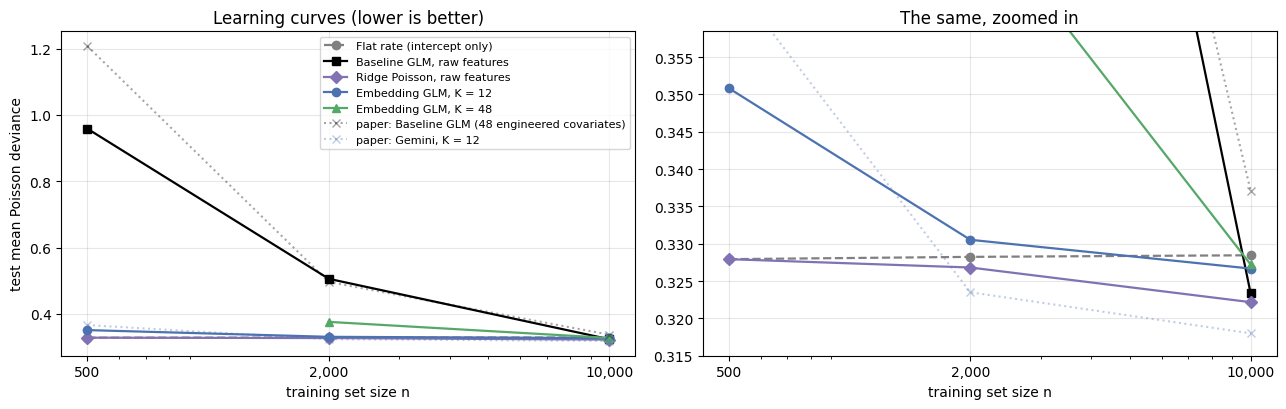

In [46]:
sizes = np.array(TRAIN_SIZES)
styles = {
    "Flat rate (intercept only)": dict(color="grey", linestyle="--", marker="o"),
    "Baseline GLM, raw features": dict(color="black", marker="s"),
    "Ridge Poisson, raw features": dict(color="#8172B3", marker="D"),
    "Embedding GLM, K = 12": dict(color="#4C72B0", marker="o"),
    "Embedding GLM, K = 48": dict(color="#55A868", marker="^"),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, zoom in zip(axes, [False, True]):
    for name, style in styles.items():
        ax.plot(sizes, PRICING_RESULTS.loc[name].to_numpy(dtype=float), label=name, linewidth=1.6, **style)
    for name, colour in [("Baseline GLM (48 engineered covariates)", "black"), ("Gemini, K = 12", "#4C72B0")]:
        ax.plot(sizes, PAPER_TABLE_1.loc[name].to_numpy(), color=colour, alpha=0.35, linestyle=":", marker="x",
                label=f"paper: {name}")
    ax.set_xscale("log")
    ax.set_xticks(sizes, [f"{n:,}" for n in sizes])
    ax.set_xlabel("training set size n")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("test mean Poisson deviance")
axes[0].set_title("Learning curves (lower is better)")
values = np.concatenate([PRICING_RESULTS.loc[list(styles)].to_numpy(dtype=float).ravel(), PAPER_TABLE_1.to_numpy().ravel()])
flat_top = np.nanmax(PRICING_RESULTS.loc["Flat rate (intercept only)"].to_numpy(dtype=float))
axes[1].set_ylim(np.nanmin(values) - 0.003, flat_top + 0.03)
axes[1].set_title("The same, zoomed in")
axes[0].legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

**What we see.**

- **The paper's headline replicates.** With 500 training policies the unpenalised GLM on raw features collapses (0.959; the paper's baseline 1.208), while the embedding GLM with 12 components stays near sensible values (0.351; the paper's best model 0.359). At 2,000 policies the gap is still wide (0.506 against 0.331). With K = 48 and 500 policies the GLM does not converge at all — the paper, too, shows several of its larger-K fits at n = 500 as a dash.
- **A flat rate beats every embedding GLM at small n.** Charging every policy the training set's average frequency scores 0.328 to 0.329 at every training size — better than every embedding GLM at n = 500 and at n = 2,000 (K = 12: 0.351 and 0.331). The paper reports no flat-rate row. On the whole portfolio the flat rate scores 0.330, so the paper's best n = 500 model (0.359) probably does not beat one either; at n = 2,000 its Gemini embeddings (0.3235) appear to, and ours do not.
- **At n = 500 the embedding advantage over the raw GLM is regularisation.** Twelve principal components mean 12 coefficients instead of 42, estimated from 28 claims; the raw GLM's 42 coefficients chase noise. The ridge-penalised GLM on the same raw features shows this directly: cross-validation picks the strongest penalty in the grid, 1,000, which shrinks the model to the flat rate in all but name, and it scores 0.328. That the choice sits on the edge of the grid is itself the finding: at this size the data prefer no rating factors at all, so a stronger penalty would only move the model closer still to the flat rate. At 2,000 and 10,000 policies cross-validation picks a value inside the grid (0.32 and 0.1).
- **In this single draw at 10,000 policies, the embeddings beat the flat rate but not the raw features.** The differences are a few thousandths, from one training set and without an interval. Both embedding GLMs score below the flat rate (0.3267 and 0.3272 against 0.3285), but the unpenalised raw GLM (0.3234) and the ridge GLM (0.3222) do better still. In the paper, Gemini with K = 12 beat its baseline at this size (0.3180 against 0.3371).
- **The comparison is indicative, not a replication.** Our baseline has no splines and no interactions (42 raw covariates against the paper's 48 engineered ones), our embedding model is not one of the paper's, and our test set is a fifth of the size of theirs. The prompts, however, are the paper's: its template, with its names for area, region and vehicle brand.

### 9.6 How much does one draw of 500 policies matter?

Everything above rests on **one** random draw of each training size. The 10,000 training policies we embedded split into 20 disjoint sets of 500 and 5 disjoint sets of 2,000, so we can repeat the experiment on each of them without a single further API call.

In [47]:
NOT_REPORTED.clear()
repeats = []
for n in [500, 2_000]:
    for draw in range(len(train_pool) // n):
        rows = slice(draw * n, (draw + 1) * n)
        scores = all_models(train_pool.iloc[rows], X_TRAIN_ALL.iloc[rows], TRAIN_EMB[rows])
        scores.pop("ridge alpha chosen by CV")
        repeats += [{"n": n, "draw": draw, "model": model, "deviance": value} for model, value in scores.items()]
REPEATS = pd.DataFrame(repeats)
draws = REPEATS.groupby("n")["draw"].nunique()
unreported = REPEATS[REPEATS["deviance"].isna()].groupby(["model", "n"], sort=False).size()
print(f"Draws: {draws[500]} of 500 policies and {draws[2_000]} of 2,000 policies.")
print("GLM fits not reported (not converged, or deviance above 100): "
      + (", ".join(f"{model} at n = {n:,}: {count} of {draws[n]}" for (model, n), count in unreported.items()) or "none"))
print("The spread table summarises the reported fits only; in the shares below, an unreported fit counts as not beating the flat rate.")

spread = REPEATS.groupby(["model", "n"], sort=False)["deviance"].agg(["median", "min", "max"]).unstack("n")
spread.columns = [f"{stat} (n = {n:,})" for stat, n in spread.columns]
display(spread.round(4))

flat = REPEATS[REPEATS["model"] == "Flat rate (intercept only)"].set_index(["n", "draw"])["deviance"]
beats = (
    REPEATS[REPEATS["model"] != "Flat rate (intercept only)"]
    .assign(beats_flat=lambda d: d["deviance"].to_numpy() < flat.loc[list(zip(d["n"], d["draw"]))].to_numpy())
    .groupby(["model", "n"], sort=False)["beats_flat"].mean().unstack("n")
)
beats.columns = [f"share of draws beating the flat rate (n = {n:,})" for n in beats.columns]
beats.map(lambda share: f"{share:.0%}")

Draws: 20 of 500 policies and 5 of 2,000 policies.
GLM fits not reported (not converged, or deviance above 100): Embedding GLM, K = 48 at n = 500: 8 of 20
The spread table summarises the reported fits only; in the shares below, an unreported fit counts as not beating the flat rate.


,median (n = 500),"median (n = 2,000)",min (n = 500),"min (n = 2,000)",max (n = 500),"max (n = 2,000)"
model,,,,,,
Flat rate (intercept only),0.3290,0.3283,0.3279,0.3280,0.3380,0.3293
"Baseline GLM, raw features",1.0706,0.4582,0.6791,0.3715,1.5327,0.5056
"Ridge Poisson, raw features",0.3294,0.3267,0.3279,0.3235,0.3584,0.3274
"Embedding GLM, K = 12",0.3522,0.3331,0.3371,0.3296,0.4303,0.3336
"Embedding GLM, K = 48",0.7436,0.3496,0.4186,0.3471,1.0893,0.3756


,share of draws beating the flat rate (n = 500),"share of draws beating the flat rate (n = 2,000)"
model,,
"Baseline GLM, raw features",0%,0%
"Ridge Poisson, raw features",65%,100%
"Embedding GLM, K = 12",0%,0%
"Embedding GLM, K = 48",0%,0%


For the embedding GLMs at n = 500 the single draw above was typical (K = 12: 0.351 against a median of 0.352); at n = 2,000 it was the worst of the five for the raw GLM and for K = 48, although the median gap (0.458 against 0.333) is still wide. Over 20 disjoint sets of 500 policies, neither embedding GLM beats the flat rate even once, and neither does the raw GLM; with K = 48 the GLM gives no reportable fit (not converged, or deviance above 100) in 8 of the 20 draws. The ridge GLM beats the flat rate in 65% of the draws — not much better than a coin toss: at this size cross-validation often shrinks it to the flat rate, and where it picks a weaker penalty it can do clearly worse (up to 0.358). With 2,000 policies the ridge GLM beats the flat rate in all 5 draws, the embedding GLMs still in none. The spread matters as much as the median: at n = 500 the K = 12 model ranges from 0.337 to 0.430, the K = 48 model's reported fits from 0.419 to 1.089, and the raw GLM from 0.68 to 1.53. At these sizes a single train–test split says little, and any claim about small-sample pricing needs repeated draws and a flat-rate yardstick.

None of this refutes the paper, whose embedding models, fine-tuning and sample sizes of up to 500,000 go far beyond this exercise. It does show why an actuary reads a table of deviances next to the simplest possible model before believing it.

### 9.7 Open exercises

1. **Other values of K.** Try K = 3, 6, 24, 96 and 192 at each training size. Where does the embedding GLM do best, and does the answer move with n, as the paper's Table 1 suggests it should?
2. **Another prompt, and a sensitivity check.** The paper's Appendix C offers five other templates — a prose narrative, a bare key-value list, qualitative descriptors such as "very young, newly licensed (18 years)". Write one of them, give it its own `PROMPT_VERSION`, re-embed (about USD 0.11 for 30,000 descriptions) and compare. Then repeat the paper's prompt-sensitivity check (its Appendix A): keep the scaler, PCA (K = 48, as in the paper) and GLM fitted at n = 10,000 fixed, append the line "- Favourite colour: blue" as a final item of each of the 20,000 test descriptions only, re-embed those (about USD 0.07) and compare policy by policy: the relative change in mean predicted frequency, and the share of policies whose predicted frequency rises. The paper found an increase of 16.1% with Qwen3-Embedding-0.6B, K = 48 and 500,000 training policies — a field that should not matter at all.
3. **A bigger embedding model.** Switch `PRICING_EMBED_MODEL` to `text-embedding-3-large` (about USD 0.69 for the whole set, as the cost line in section 9.3 shows). Better general-purpose embeddings are not guaranteed to be better rating factors.
4. **Raw features plus a few components.** Add the first 3 or 6 embedding components to the baseline GLM's raw features. Does that beat both of its parents, and at which n does it start to?

Finally, the complete bill of this session, from the ledger of section 1.

In [48]:
spend_report()

calls  input_tokens  cached_tokens  output_tokens  cost_usd  cost_usd_cold_run  cost_usd_no_cache
purpose               model                                                                                                                     
embed chunks          text-embedding-3-large      23       1339697              0              0    0.1742             0.1742             0.1742
embed prompts         text-embedding-3-large       1           171              0              0    0.0000             0.0000             0.0000
walkthrough           gpt-6-luna                  10         56947          16008           3802    0.0062             0.0071             0.0076
benchmark             gpt-6-luna                  27        154911         154830           5440    0.0043             0.0043             0.0182
                      gpt-5.4-mini-2026-03-17     27        154911         113152           2283    0.0501             0.0611             0.1265
                      gpt-5.4-2026-03-05          27        154911         122624           2272    0.1455             0.2105             0.4214
schema experiment     gpt-6-luna                   9         48420          43257           3730    0.0028             0.0038             0.0067
                      gpt-5.4-mini-2026-03-17      9         48420          43264            600    0.0098             0.0186             0.0390
                      gpt-5.4-2026-03-05           9         48420          40704            601    0.0385             0.0644             0.1301
embed pricing prompts text-embedding-3-small      30       5290528              0              0    0.1058             0.1058             0.1058
total                                            172       7297336         533839          18728    0.5371             0.6499             1.0294

**Next notebook:** Case Study 3, `05_cs3_vehicle_damage_vision`.